<a href="https://colab.research.google.com/github/preethipalanisamy12-source/AlmaBetter-Projects/blob/main/EDA_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -

# **SupplyChain Pulse: Decoding Global Health Commodity Delivery Through EDA**
An Exploratory Data Analysis of SCMS Delivery History to Drive Efficiency, Reduce Costs, and Accelerate Life-Saving Shipments Across 43 Countries.

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Analysed by**     - Preethi P

# **Project Summary -**

The SCMS (Supply Chain Management System) Delivery History dataset captures 10,324 shipment records spanning **2006–2015**, documenting the **global distribution** of HIV/AIDS antiretroviral medications, diagnostic test kits, malaria treatments, and antimalarial drugs across **43 countries** — primarily across Sub-Saharan Africa, with additional shipments to South and Southeast Asia, the Caribbean, and Latin America.
Each record tracks the complete journey of a commodity from procurement request to client delivery, including vendor identity, shipment mode (Air, Air Charter, Truck, Ocean), scheduled vs. actual delivery dates, freight costs, insurance, pack pricing, unit pricing, and manufacturing origin. With **73 distinct vendors** — predominantly Indian pharmaceutical manufacturers — and over **1.63 billion dollars in total shipment value**, this dataset represents a live window into one of the world's most critical humanitarian supply chains.
The core objective of this EDA is to **help FedEx Logistics streamline operations** by surfacing patterns that answer three high-impact business questions: Where are deliveries being delayed, and why? Which shipment modes and vendors deliver the best cost efficiency? And What trends, correlations, and outliers in the data point to systemic supply chain improvements that can lower costs and improve delivery reliability for millions of patients worldwide.

# **GitHub Link -**

https://github.com/preethipalanisamy12-source/AlmaBetter-Projects.git

# **Problem Statement**


**Write Problem Statement Here.**

FedEx Logistics operates a complex global supply chain where maintaining delivery timelines and cost-effectiveness is critical for a competitive advantage. However, the current logistics process indicates significant inefficiencies across three key dimensions.


*   First, **consistent variances between the Scheduled Delivery Date and
Delivered to Client Date** suggest persistent logistical bottleneck.
*   Second, administrative delays are evident in the procurement lead time, specifically the **gap between the PQ First Sent to Client Date and the PO Sent to Vendor Date.**
*   Finally, **unpredictable fluctuations in Freight Cost (USD) and Unit Price** across different Vendors, Shipment Modes (e.g., Air vs. Air Charter), and Manufacturing Sites highlight a lack of cost optimization.

Failure to identify and mitigate these drivers through data-driven analysis risks increased operational expenditures and reduced customer satisfaction, potentially leading to negative business growth.



#### **Define Your Business Objective?**

The primary objective of this exploratory data analysis is to evaluate FedEx Logistics' global operations using a structured Univariate, Bivariate, and Multivariate (UBM) analytical approach.
This project aims to:


*  **Identify high-variance delivery nodes** by correlating Vendors and Manufacturing Sites with actual delivery delays.
*  **Pinpoint administrative bottlenecks** within the procurement cycle by analyzing the time elapsed between quotation and order placement
*  **Evaluate cost-efficiency** by investigating the relationship between Shipment Modes, Line Item Insurance, and molecular Unit Pricing

The ultimate goal is to transform these findings into actionable insights that will allow FedEx Logistics to streamline supply chain operations, reduce unnecessary freight expenses, and ensure a positive business impact for both the company and its global clientele.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [154]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [155]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 1000)

### Dataset Loading

In [156]:
# Load Dataset
url = "https://raw.githubusercontent.com/preethipalanisamy12-source/AlmaBetter-Projects/refs/heads/main/SCMS_dataset.csv"
scms_data = pd.read_csv(url)

### Dataset First View

In [157]:
# Dataset First Look
print(scms_data.head())
print(scms_data.tail())

   ID Project Code            PQ # PO / SO # ASN/DN #        Country  \
0   1   100-CI-T01  Pre-PQ Process    SCMS-4    ASN-8  Côte d'Ivoire   
1   3   108-VN-T01  Pre-PQ Process   SCMS-13   ASN-85        Vietnam   
2   4   100-CI-T01  Pre-PQ Process   SCMS-20   ASN-14  Côte d'Ivoire   
3  15   108-VN-T01  Pre-PQ Process   SCMS-78   ASN-50        Vietnam   
4  16   108-VN-T01  Pre-PQ Process   SCMS-81   ASN-55        Vietnam   

  Managed By  Fulfill Via Vendor INCO Term Shipment Mode  \
0   PMO - US  Direct Drop              EXW           Air   
1   PMO - US  Direct Drop              EXW           Air   
2   PMO - US  Direct Drop              FCA           Air   
3   PMO - US  Direct Drop              EXW           Air   
4   PMO - US  Direct Drop              EXW           Air   

  PQ First Sent to Client Date PO Sent to Vendor Date Scheduled Delivery Date  \
0               Pre-PQ Process      Date Not Captured                2-Jun-06   
1               Pre-PQ Process      Date Not



*   33 Variables (Max Row: 10,323 | Max ID: 86,823) ➔ **Non-continuous ID range** — contains only the subset of whole data.

*  **Date, Cost & Weight Columns** (**Mixed Qualitative Text**) ➔ "Pre-PQ Process", "Freight Included", "See DN-#" — placeholders require heavy cleaning and type-casting.

### Dataset Rows & Columns count

In [158]:
# Dataset Rows & Columns count
print(scms_data.shape)
print(scms_data.index)
print(scms_data.columns)

(10324, 33)
RangeIndex(start=0, stop=10324, step=1)
Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')


### Dataset Information

In [159]:
# Dataset Info
scms_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

*  **Date Columns (Stored as Object)** ➔ Contains placeholders preventing type conversion to datetime64.

*  **Cost & Weight (Stored as Object)** ➔ Contains placeholders preventing type conversion to float64.

*  **3 Null Columns (Text Placeholders)**➔ Standard null-counts underreport the true data gaps.

#### Duplicate Values

In [160]:
print(f"Complete row duplicates : {scms_data.duplicated().sum()}")

print("PO/SO# duplicates:", scms_data['PO / SO #'].duplicated().sum())
print("ASN/DN# duplicates:", scms_data['ASN/DN #'].duplicated().sum())

item_cols = ['PO / SO #', 'ASN/DN #', 'Item Description', 'Line Item Quantity', 'Line Item Value']

item_dupes = scms_data.duplicated(subset= item_cols, keep=False)
print(f"Item Duplicates: {item_dupes.sum()}")

Complete row duplicates : 0
PO/SO# duplicates: 4091
ASN/DN# duplicates: 3294
Item Duplicates: 32


* **Purchase Orders & Shipment Notices**: High volume of duplicate entries. Conversely, there is a low volume of actual item duplicates, which confirms the data is structured as a line-item ledger.

* **Quantity Duplicates** (Same Item): Identified as **Order Splitting **(multiple line items or partial shipments for the same product).

* **Shipment Notice Duplicates**: Source unclear; requires targeted investigation.

#### Missing Values/Null Values

In [161]:
# Missing Values/Null Values Count
standard_nulls = scms_data.isnull().sum() #Missing values as NaN - only 3 columns.
print(standard_nulls)

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [162]:
scms_hidden_nulls = scms_data.copy()

# 1. Replacing exact text phrases which are placeholders.
exact_texts = [
    'Pre-PQ Process',
    'Date Not Captured',
    'Weight Captured Separately',
    'Invoiced Separately',
    'Freight Included in Commodity Cost',
    'N/A - From RDC'
]
scms_hidden_nulls = scms_hidden_nulls.replace(exact_texts, np.nan)

# 2. Replacing partial regex patterns.
scms_hidden_nulls = scms_hidden_nulls.replace(r'.*See.*', np.nan, regex=True)

# 3. Calculating total null values
total_nulls = scms_hidden_nulls.isnull().sum().sort_values(ascending=False)
print(total_nulls)

PO Sent to Vendor Date          5732
Vendor INCO Term                5404
Freight Cost (USD)              4126
Weight (Kilograms)              3952
PQ First Sent to Client Date    2681
PQ #                            2681
Dosage                          1736
Shipment Mode                    360
Line Item Insurance (USD)        287
ID                                 0
Managed By                         0
Country                            0
Scheduled Delivery Date            0
Fulfill Via                        0
ASN/DN #                           0
PO / SO #                          0
Project Code                       0
Sub Classification                 0
Product Group                      0
Delivery Recorded Date             0
Delivered to Client Date           0
Brand                              0
Vendor                             0
Molecule/Test Type                 0
Item Description                   0
Line Item Quantity                 0
Unit of Measure (Per Pack)         0
D

**Visualising Null Values**

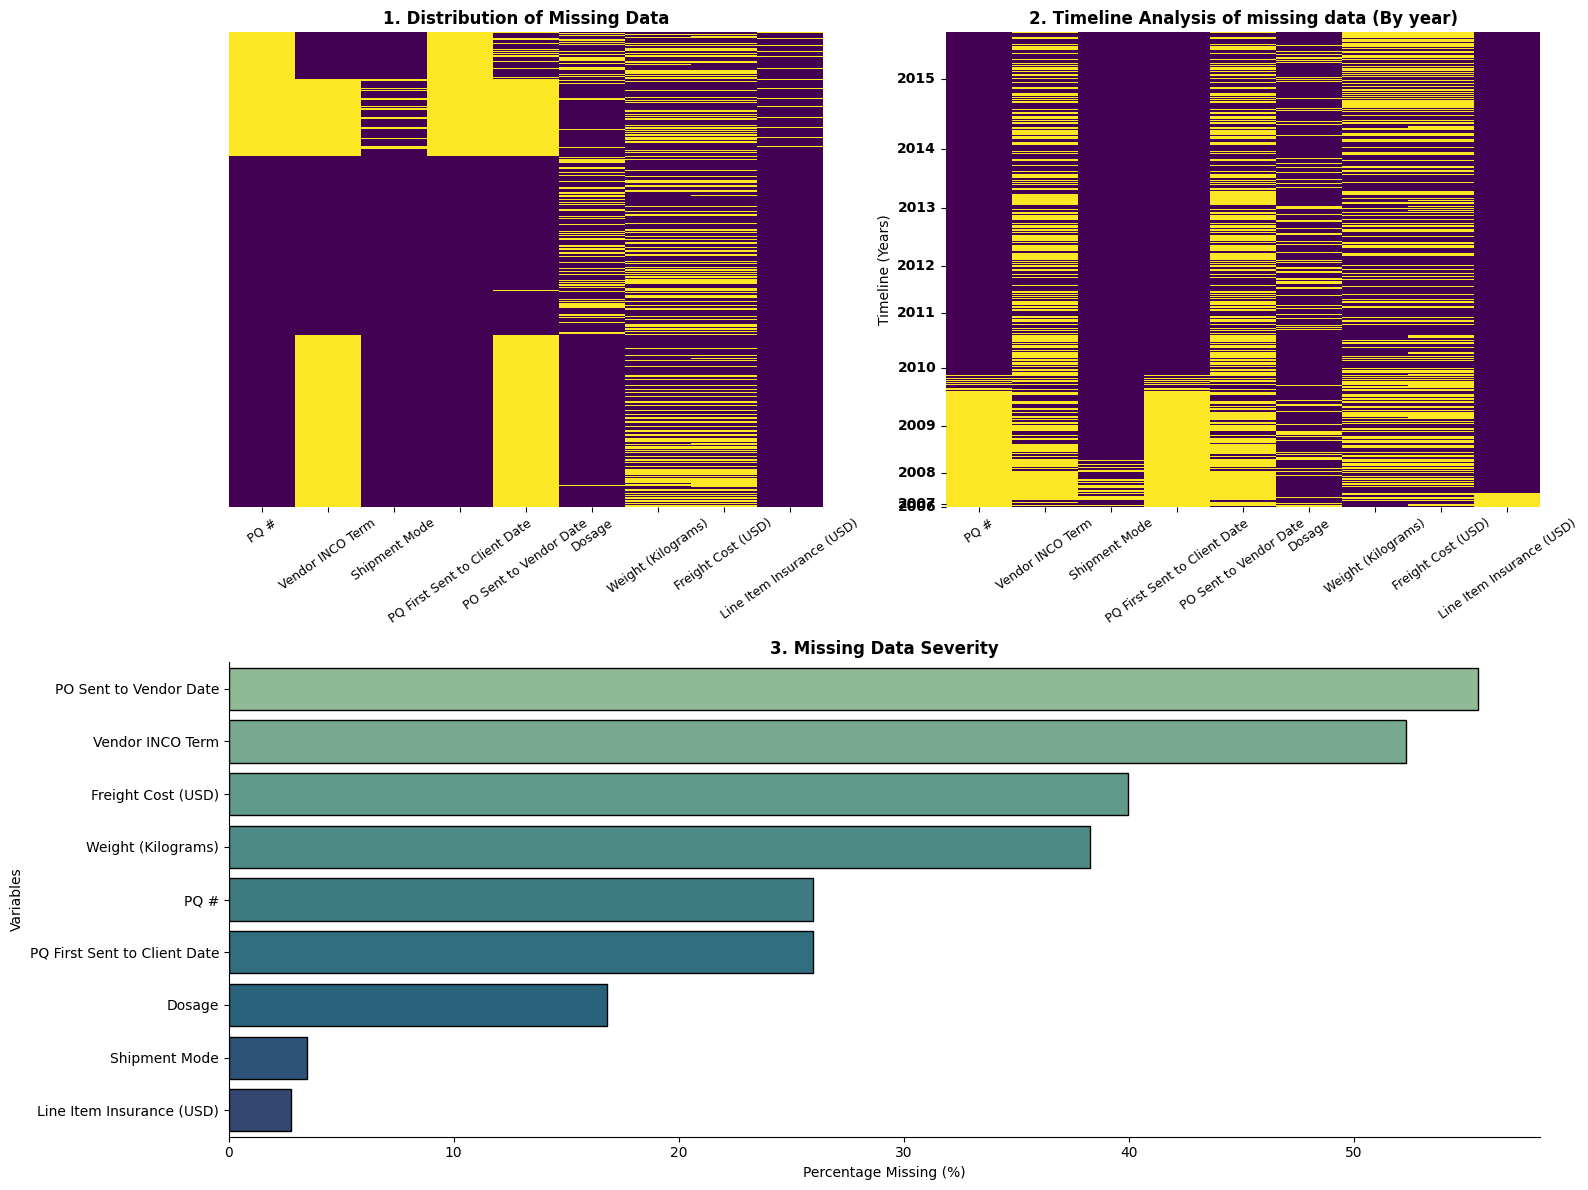

In [163]:
# Creating Layout
fig = plt.figure(figsize=(16, 12))
ax1 = plt.subplot(2, 2, 1)
ax2 = plt.subplot(2, 2, 2)
ax3 = plt.subplot(2, 1, 2)

#extracting only the columns with null values for clear visualisation
all_null_cols = scms_hidden_nulls.columns[scms_hidden_nulls.isnull().any()].tolist()


# CHART 1: UNSORTED HEATMAP
sns.heatmap(scms_hidden_nulls[all_null_cols].isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=ax1)
ax1.set_title("1. Distribution of Missing Data", fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=35, labelsize=9)

# CHART 2: CHRONOLOGICAL HEATMAP
scms_hidden_nulls['Scheduled Delivery Date'] = pd.to_datetime(scms_hidden_nulls['Scheduled Delivery Date'], errors='coerce')

#prepping the data for sorting the data yearwise
df_clean_dates = scms_hidden_nulls.dropna(subset=['Scheduled Delivery Date'])
df_chronological = df_clean_dates.sort_values(by='Scheduled Delivery Date', ascending=True).reset_index(drop=True)
df_chronological['Year'] = df_chronological['Scheduled Delivery Date'].dt.year
year_positions = df_chronological.groupby('Year').idxmin()['Scheduled Delivery Date']

#plotting the map in chronocological order
sns.heatmap(df_chronological[all_null_cols].isnull(), cbar=False, cmap='viridis', ax=ax2)
ax2.set_yticks(year_positions.values)
ax2.set_yticklabels(year_positions.index, rotation=0, fontweight='bold')
ax2.invert_yaxis()  # Keeps oldest years at the top flowing down
ax2.set_title("2. Timeline Analysis of missing data (By year)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Timeline (Years)")
ax2.tick_params(axis='x', rotation=35, labelsize=9)

# CHART 3: SEVERITY BAR CHART (ALL NULL COLUMNS)

#calculating the % of null values
null_pct = (scms_hidden_nulls.isnull().mean() * 100).reset_index()
null_pct.columns = ['Column', 'Percentage']
null_pct = null_pct[null_pct['Percentage'] > 0].sort_values(by='Percentage', ascending=False)

#horizontal severity comparison bar chart
sns.barplot(x='Percentage', y='Column', data=null_pct, palette='crest', hue='Column', edgecolor='black', ax=ax3)
ax3.set_title("3. Missing Data Severity", fontsize=12, fontweight='bold')
ax3.set_xlabel("Percentage Missing (%)")
ax3.set_ylabel("Variables")
sns.despine(ax=ax3)

plt.tight_layout()
plt.show()

**Insights from visualisation**

**Chart 1 (Missing Value Distribution)**➔ Freight cost and weight nulls are scattered uniformly — other missing data is highly concentrated.

**Chart 2 (Chronological Correlation)** ➔ Concentrated nulls align with pre-2010 timelines — suggests poor data logging standards in legacy records.

**Chart 3 (Missingness Severity)** ➔ Null density peaks in columns containing text placeholders — demands extensive, targeted data cleaning.


### What did you know about your dataset?

*  **End-to-End Scope**: The SCMS dataset provides comprehensive visibility into the global health product supply chain from 2006 to 2015 across 33 variables
*  **Sampling Context**: Non-continuous Order IDs (reaching 86,823) confirm that we are analysing an operational subset rather than a complete transactional archive
*  **Technical Roadblocks**: Qualitative strings such as "Pre-PQ Process" and "Date Not Captured" function as operational nulls, preventing immediate numerical typecasting and timeline analysis
*  **Data Maturity Trend**: Integrity gaps in quotations and insurance are concentrated in records pre-2010, indicating a legacy of inconsistent logging that improved as digital tracking matured
*  **Line-Item Architecture**: Logical duplicates in PO/SO and ASN/DN numbers suggest that orders and shipments are frequently consolidated, containing multiple distinct product line items per transaction
*  **Logistics Metadata**: Detailed shipment modes (Air, Truck, Ocean, Air Charter) and weight references (e.g., "See ASN-...") provide the categorical depth required for a multi-layered analysis of delivery efficiency

## ***2. Understanding Your Variables***

In [164]:
# Dataset Columns
scms_data.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

In [165]:
# Dataset Describe
scms_data.describe()


,ID,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
std,31944.332496,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568
min,1.000000,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000


In [166]:
scms_data.describe(include = 'object')

,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD)
count,10324,10324,10324,10324,10324,10324,10324,10324,9964,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,10324,8588,10324,10324,10324,10324,10324
unique,142,1237,6233,7030,43,4,2,8,4,765,897,2006,2093,2042,5,6,73,184,86,48,54,17,88,2,4688,6733
top,116-ZA-T30,Pre-PQ Process,SCMS-199289,ASN-19166,South Africa,PMO - US,From RDC,N/A - From RDC,Air,Pre-PQ Process,N/A - From RDC,29-Aug-14,29-Aug-14,29-Aug-14,ARV,Adult,SCMS from RDC,"Efavirenz 600mg, tablets, 30 Tabs",Efavirenz,Generic,300mg,Tablet,"Aurobindo Unit III, India",Yes,Weight Captured Separately,Freight Included in Commodity Cost
freq,768,2681,67,54,1406,10265,5404,5404,6113,2476,5404,97,74,67,8550,6595,5404,755,1125,7285,990,3532,3172,7030,1507,1442


### Variables Description

* **Wide Volume Range**: Order quantities vary from 1 to 619,999 units, reflecting both small emergency shipments and large-scale replenishments.
* **Pack Size Variability**: Packs range from 1 to 1,000 units, influencing shipment weight and freight costs.
* **Incomplete Insurance Data**: Insurance values reach $7,700, but many records are marked as "Invoiced Separately", limiting total cost visibility.
* **Complex Supply Network**: The dataset spans 142 initiatives, 73 vendors, 88 manufacturing sites, and 43 countries.
* **Potential Delivery Drivers**: High vendor and manufacturing-site diversity may contribute to lead-time variability.
* **Priority Assessment Needed**: Further analysis is required to determine whether First Line Designated products receive faster processing.

### Check Unique Values for each variable.

In [167]:
# Check Unique Values for each variable.
scms_data.nunique().sort_values(ascending = False)

,0
ID,10324
Line Item Value,8741
ASN/DN #,7030
Freight Cost (USD),6733
Line Item Insurance (USD),6722
PO / SO #,6233
Line Item Quantity,5065
Weight (Kilograms),4688
Delivered to Client Date,2093
Delivery Recorded Date,2042


## 3. ***Data Wrangling***

### Data Wrangling Code

Handling Duplicates

In [168]:
item_cols = ['PO / SO #','ASN/DN #', 'Item Description', 'Line Item Quantity','Manufacturing Site','First Line Designation']

#checking for duplication other than critical columns
duplicate_records = scms_data[scms_data.duplicated(subset=item_cols, keep=False)]
print(duplicate_records.sort_values(item_cols))

#dropping 4 columns - complete duplication except ID
scms_data.drop_duplicates(
    subset=item_cols,
    keep='first',
    inplace = True
)

         ID Project Code            PQ #    PO / SO #   ASN/DN #      Country  \
4371  43250   105-SS-T30       FPQ-12623  SCMS-200920  ASN-21751  South Sudan   
5781  68128   105-SS-T30       FPQ-12623  SCMS-200920  ASN-21751  South Sudan   
1126  10692   125-HT-T01  Pre-PQ Process      SO-1291     DN-686        Haiti   
1520  11246   125-HT-T01  Pre-PQ Process      SO-1291     DN-686        Haiti   
2134  12146   100-ZW-T01  Pre-PQ Process       SO-710     DN-488     Zimbabwe   
2135  12147   100-ZW-T01  Pre-PQ Process       SO-710     DN-488     Zimbabwe   
1957  11882   100-ZW-T01  Pre-PQ Process       SO-716     DN-770     Zimbabwe   
2577  12792   100-ZW-T01  Pre-PQ Process       SO-716     DN-770     Zimbabwe   

     Managed By  Fulfill Via Vendor INCO Term Shipment Mode  \
4371   PMO - US  Direct Drop              EXW           Air   
5781   PMO - US  Direct Drop              EXW           Air   
1126   PMO - US     From RDC   N/A - From RDC           Air   
1520   PMO - US   

Handling Missing/Null Values

In [169]:
null_pct = (scms_hidden_nulls.isnull().mean() * 100).round(2).sort_values(ascending=False)

print(null_pct)

PO Sent to Vendor Date          55.52
Vendor INCO Term                52.34
Freight Cost (USD)              39.97
Weight (Kilograms)              38.28
PQ First Sent to Client Date    25.97
PQ #                            25.97
Dosage                          16.82
Shipment Mode                    3.49
Line Item Insurance (USD)        2.78
ID                               0.00
Managed By                       0.00
Country                          0.00
Scheduled Delivery Date          0.00
Fulfill Via                      0.00
ASN/DN #                         0.00
PO / SO #                        0.00
Project Code                     0.00
Sub Classification               0.00
Product Group                    0.00
Delivery Recorded Date           0.00
Delivered to Client Date         0.00
Brand                            0.00
Vendor                           0.00
Molecule/Test Type               0.00
Item Description                 0.00
Line Item Quantity               0.00
Unit of Meas

In [170]:
# 1.Freight cost and weight column "see Id" values are filled with ref Id via INDEX-MATCH in spreadsheet
url = "https://raw.githubusercontent.com/preethipalanisamy12-source/AlmaBetter-Projects/refs/heads/main/SCMS(%20freight%2C%20cost%20resolved).csv"
scms_clean = pd.read_csv(url)

scms_clean.drop(columns = ['Weight (Kilograms)','Freight Cost (USD)'], inplace = True)
scms_clean

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Line Item Insurance (USD),Freight Cost resolved,Weight resolved
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2-Jun-06,2-Jun-06,2-Jun-06,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,NaN,780.34,13
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,14-Nov-06,14-Nov-06,14-Nov-06,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",Yes,NaN,4521.5,358
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,27-Aug-06,27-Aug-06,27-Aug-06,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,NaN,1653.78,171
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,1-Sep-06,1-Sep-06,1-Sep-06,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,NaN,16007.06,1855
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,11-Aug-06,11-Aug-06,11-Aug-06,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",Yes,NaN,45450.08,7590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10319,86818,103-ZW-T30,FPQ-15197,SO-50020,DN-4307,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,10/16/14,N/A - From RDC,31-Jul-15,15-Jul-15,20-Jul-15,ARV,Pediatric,SCMS from RDC,"Lamivudine/Nevirapine/Zidovudine 30/50/60mg, d...",Lamivudine/Nevirapine/Zidovudine,Generic,30/50/60mg,Chewable/dispersible tablet - FDC,60,166571,599655.60,3.60,0.06,"Mylan, H-12 & H-13, India",No,705.79,46111.55,25880
10320,86819,104-CI-T30,FPQ-15259,SO-50102,DN-4313,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Truck,10/24/14,N/A - From RDC,31-Jul-15,6-Aug-15,7-Aug-15,ARV,Adult,SCMS from RDC,"Lamivudine/Zidovudine 150/300mg, tablets, 60 Tabs",Lamivudine/Zidovudine,Generic,150/300mg,Tablet - FDC,60,21072,137389.44,6.52,0.11,Hetero Unit III Hyderabad IN,No,161.71,14734.92,4426
10321,86821,110-ZM-T30,FPQ-14784,SO-49600,DN-4316,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,8/12/14,N/A - From RDC,31-Aug-15,25-Aug-15,3-Sep-15,ARV,Adult,SCMS from RDC,Efavirenz/Lamivudine/Tenofovir Disoproxil Fuma...,Efavirenz/Lamivudine/Tenofovir Disoproxil Fuma...,Generic,600/300/300mg,Tablet - FDC,30,514526,5140114.74,9.99,0.33,Cipla Ltd A-42 MIDC Mahar. IN,No,5284.04,Freight Included in Commodity Cost,Weight Captured Separately
10322,86822,200-ZW-T30,FPQ-16523,SO-51680,DN-4334,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,7/1/15,N/A - From RDC,9-Sep-15,4-Aug-15,11-Aug-15,ARV,Adult,SCMS from RDC,"Lamivudine/Zidovudine 150/300mg, tablets, 60 Tabs",Lamivudine/Zidovudine,Generic,150/300mg,Tablet - FDC,60,17465,113871.80,6.52,0.11,Mylan (formerly Matrix) Nashik,Yes,134.03,Freight I

In [171]:
# 2.dropping dosage column - not in scope of logistics analysis
scms_clean.drop(columns = ['Dosage'], inplace = True)


In [172]:
# 3.PO Sent to Vendor Date placeholders kept as Nan
scms_clean['PO Sent to Vendor Date'].replace(
    ['Date Not Captured', 'N/A - From RDC'],np.nan, inplace = True)

In [173]:
# 4.shipment NaNs with mode based on Country.
mode_fill = scms_clean.groupby(['Country','Fulfill Via'])['Shipment Mode'] \
              .transform(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
scms_clean['Shipment Mode'] = scms_clean['Shipment Mode'].fillna(mode_fill)

In [174]:
# 5.Finding the insurance according to the value of the item.
# Replacing the missing values with meadian of that insurance value.

ratio = (scms_clean.loc[scms_clean['Line Item Insurance (USD)']>0, 'Line Item Insurance (USD)'] /
         scms_clean.loc[scms_clean['Line Item Insurance (USD)']>0, 'Line Item Value']).median()
missing_insurance = scms_clean['Line Item Insurance (USD)'].isna()
scms_clean.loc[missing_insurance, 'Line Item Insurance (USD)'] = scms_clean.loc[missing_insurance, 'Line Item Value'] * ratio

In [175]:
# 6. Converting other placeholders to null as they can't be logically imputed.
placeholders = ['Pre-PQ Process', 'Date Not Captured', 'Weight Captured Separately',
                'Invoiced Separately', 'Freight Included in Commodity Cost', 'N/A - From RDC']
scms_clean.replace(placeholders, np.nan, inplace = True)

scms_clean.isnull().sum().sort_values(ascending = False)

,0
PO Sent to Vendor Date,5732
Vendor INCO Term,5404
PQ #,2681
PQ First Sent to Client Date,2681
Freight Cost resolved,1786
Weight resolved,1633
ASN/DN #,0
ID,0
Fulfill Via,0
Managed By,0


In [176]:
# 7. INCO term - handling missing values
print(scms_clean['Vendor INCO Term'].isnull().mean()*100)


scms_clean['PO Sent to Vendor Date'] = pd.to_datetime(scms_clean['PO Sent to Vendor Date'], errors='coerce')

scms_clean['Year'] = scms_clean['PO Sent to Vendor Date'].dt.year
scms_clean.groupby('Year')['Vendor INCO Term'] \
          .apply(lambda x: x.isna().mean()*100) \
          .round(2)

#Vendor INCO Term contained 52.34% missing values.
#Missingness remained high across all years, including the most recent years (>35%).
#No sufficiently complete time period was identified for reliable subset analysis.

scms_clean.drop(columns = ['Vendor INCO Term'], inplace = True)

52.34405269275475


Type Casting


In [177]:
# Date columns
date_cols = ['PQ First Sent to Client Date', 'PO Sent to Vendor Date',
             'Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date']

for col in date_cols:
    scms_clean[col] = pd.to_datetime(scms_clean[col], errors='coerce')

# Numeric columns stored as text
num_cols = ['Freight Cost resolved', 'Weight resolved ']

for col in num_cols:
    scms_clean[col] = pd.to_numeric(scms_clean[col], errors='coerce')

print(scms_clean.dtypes)

ID                                       int64
Project Code                            object
PQ #                                    object
PO / SO #                               object
ASN/DN #                                object
Country                                 object
Managed By                              object
Fulfill Via                             object
Shipment Mode                           object
PQ First Sent to Client Date    datetime64[ns]
PO Sent to Vendor Date          datetime64[ns]
Scheduled Delivery Date         datetime64[ns]
Delivered to Client Date        datetime64[ns]
Delivery Recorded Date          datetime64[ns]
Product Group                           object
Sub Classification                      object
Vendor                                  object
Item Description                        object
Molecule/Test Type                      object
Brand                                   object
Dosage Form                             object
Unit of Measu

Renaming selected columns for improved readability and cleaner visualizations.

In [178]:
scms_clean = scms_clean.rename(columns={
    'PQ First Sent to Client Date': 'PQ_Sent_Date',
    'PO Sent to Vendor Date': 'PO_Sent_Date',
    'Delivered to Client Date': 'Delivered_Date',
    'Line Item Quantity' : 'Quantity',
    'Line Item Value' : 'Value',
    'Weight resolved ': 'Weight_KG',
    'Freight Cost resolved': 'Freight_Cost_USD',
    'Line Item Insurance (USD)': 'Insurance_USD'
})

In [179]:
scms_clean.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Shipment Mode', 'PQ_Sent_Date',
       'PO_Sent_Date', 'Scheduled Delivery Date', 'Delivered_Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Quantity', 'Value',
       'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Insurance_USD', 'Freight_Cost_USD',
       'Weight_KG', 'Year'],
      dtype='object')

Handling Outliers

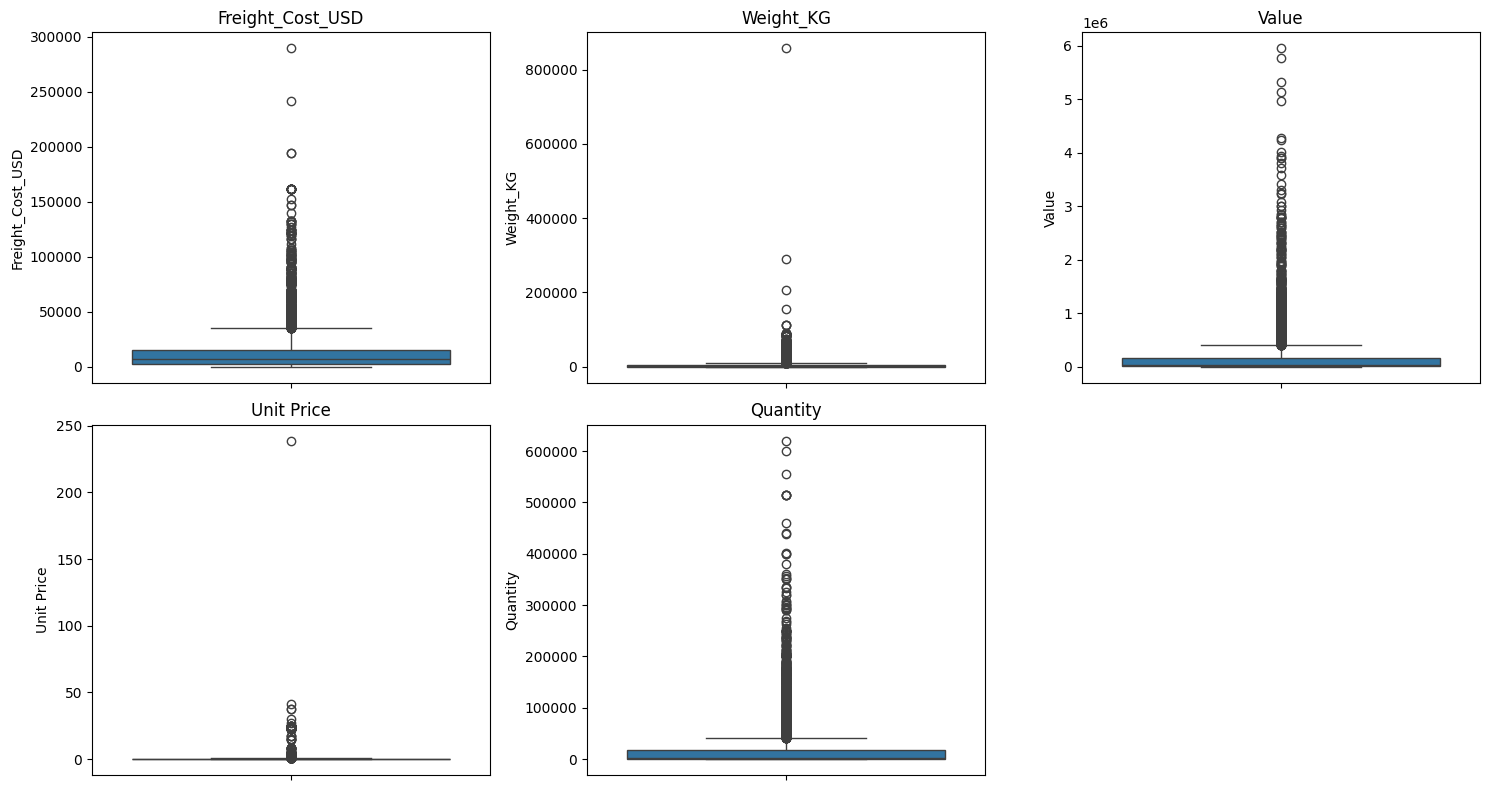

In [180]:
num_cols = [
    'Freight_Cost_USD',
    'Weight_KG',
    'Value',
    'Unit Price',
    'Quantity'
]

plt.figure(figsize=(15, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=scms_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

* Freight Cost & Weight: A few exceptionally large shipments drive extreme values.
* Line Value: Contains several high-value procurement orders.
* Unit Price: Most items are low-cost, with a few premium products.
* Quantity: Bulk purchases create very large order volumes.

**Overall**: All variables likely representing genuine large-scale supply chain transactions rather than data errors.

Data Validation

In [181]:
#looking for dates where delivered date is lesser than the Purchase Order date.
illogical_dates = scms_clean['Delivered_Date'] < scms_clean['PO_Sent_Date']
scms_clean.loc[
    illogical_dates,
    ['PO_Sent_Date', 'Delivered_Date', 'Country', 'Vendor', 'Fulfill Via']
].head(20)

,PO_Sent_Date,Delivered_Date,Country,Vendor,Fulfill Via
454,2008-04-28,2008-01-03,Haiti,REINBOLD EXPORT IMPORT,Direct Drop
1637,2007-11-12,2007-01-24,South Africa,"JSI R&T INSTITUTE, INC.",Direct Drop
2698,2014-06-23,2014-01-14,Dominican Republic,"ABBVIE, SRL (FORMALLY ABBOTT LABORATORIES INTE...",Direct Drop
3387,2015-05-29,2015-05-26,South Africa,PHARMACY DIRECT,Direct Drop
4906,2014-06-26,2014-06-25,South Africa,PHARMACY DIRECT,Direct Drop


In [182]:
#keeping illogical dates as null.
scms_clean.loc[illogical_dates, 'Delivered_Date'] = np.nan

In [183]:
for col in ['Unit Price', 'Pack Price', 'Value']:
    zero_count = (scms_clean[col] == 0).sum()
    print(col, '- zero value rows:', zero_count)

# numeric cols - price, value has 0 values - donated or non-commercial shipments
# keeping as it is

Unit Price - zero value rows: 103
Pack Price - zero value rows: 18
Value - zero value rows: 17


### What all manipulations have you done and insights you found?

### Data Wrangling & Key Insights

* **Duplicate Handling:** Investigated repeated POs and ASNs, distinguished legitimate multi-line and split-shipment records from true duplicates, and removed only confirmed duplicate entries.
* **Missing Value Treatment:** Replaced placeholder texts with `NaN`, recovered freight cost and weight from ASN references, imputed missing Shipment Mode using business logic, and retained genuine unknown values. Dropped **Vendor INCO Term** due to excessive missingness (>50%).
* **Type Casting:** Converted date columns to datetime format and cost, quantity, weight, and insurance fields to numeric types for accurate calculations.
* **Column Renaming:** Simplified lengthy column names to improve readability and reduce clutter in visualizations.
* **Outlier Assessment:** Identified extreme values using boxplots and retained them, as they represent genuine bulk procurements, large shipments, and high-value transactions.
* **Data Validation:** Checked for temporal inconsistencies and corrected 5 records where delivery dates occurred before PO sent dates.

**Key Insight:** The dataset reflects real-world humanitarian supply chain operations, including multi-line procurement orders, shipment-level cost references, large-scale bulk movements, and a small number of zero-value transactions likely representing donated or non-commercial shipments.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Hypothesis & Assumptions

## Hypothesis

Supply chain performance is expected to vary by shipment mode, vendor, country, and procurement lead time. Countries with longer lead times and greater reliance on air freight may experience higher delays and lower budget efficiency. Overall performance is expected to improve between 2006 and 2015 as the program matured.

## Assumptions

- Delivery delay is measured against the scheduled delivery date.
- Freight Cost and Weight values have been cleaned and treated as numeric.
- Zero insurance values are considered valid.
- Records with missing delivery dates are excluded from delay and lead-time analysis but retained for other analyses.
- The dataset contains only completed shipments; cancelled or unfulfilled orders are outside the scope of this study.

In [184]:
# DATA TRANSFORMATION

scms_viz = scms_clean.copy()

# --- 1. DELIVERY DELAY (Days) ---
# Positive = late | Negative = early | 0 = exact
scms_viz['Delivery_Delay_Days'] = (
    scms_viz['Delivered_Date'] - scms_viz['Scheduled Delivery Date']
).dt.days


# --- 2. ON-TIME FLAG ---
# 1 = on time or early | 0 = delayed
scms_viz['On_Time_Flag'] = (scms_viz['Delivery_Delay_Days'] <= 0).astype(int)


# --- 3. DELAY CATEGORY (Clinical Risk Framing) ---
# 14-day threshold = typical buffer stock horizon in humanitarian supply chains
def classify_delay(days):
    if pd.isna(days):
      return 'Unknown'
    elif days <= 0:
      return 'On Time'
    elif days <= 14:
      return 'Moderate Delay'
    else:
      return 'Critical Delay'

scms_viz['Delay_Category'] = scms_viz['Delivery_Delay_Days'].apply(classify_delay)


# --- 4. PROCUREMENT LEAD TIME (Days) ---
# Time from PQ sent to client → PO sent to vendor (internal approval cycle)
scms_viz['Procurement_Lead_Time'] = (
    scms_viz['PO_Sent_Date'] - scms_viz['PQ_Sent_Date']
).dt.days


# --- 5. FREIGHT COST COLUMNS ---
# Freight as % of shipment value — donor budget efficiency metric
scms_viz['Freight_Pct_Value'] = (
    scms_viz['Freight_Cost_USD'] / scms_viz['Value'] * 100
)
# Freight cost per KG — detects modal cost inefficiency
scms_viz['Freight_Per_KG'] = (
    scms_viz['Freight_Cost_USD'] / scms_viz['Weight_KG']
)


# --- 6. YEAR AND QUARTER ---
scms_viz['Year']         = scms_viz['Scheduled Delivery Date'].dt.year
scms_viz['Quarter']      = scms_viz['Scheduled Delivery Date'].dt.quarter
scms_viz['Year_Quarter'] = scms_viz['Scheduled Delivery Date'].dt.to_period('Q').astype(str)


# --- 7. COST PER UNIT ---
# Pack-level unit economics — vendor pricing benchmark metric
scms_viz['Cost_Per_Unit'] = scms_viz['Value'] / scms_viz['Quantity']

In [185]:
scms_viz.to_csv("scms_viz_main.csv")

# UNIVARIATE ANALYSIS

#### Chart - 1 - Freight Cost & Quantity Distributions

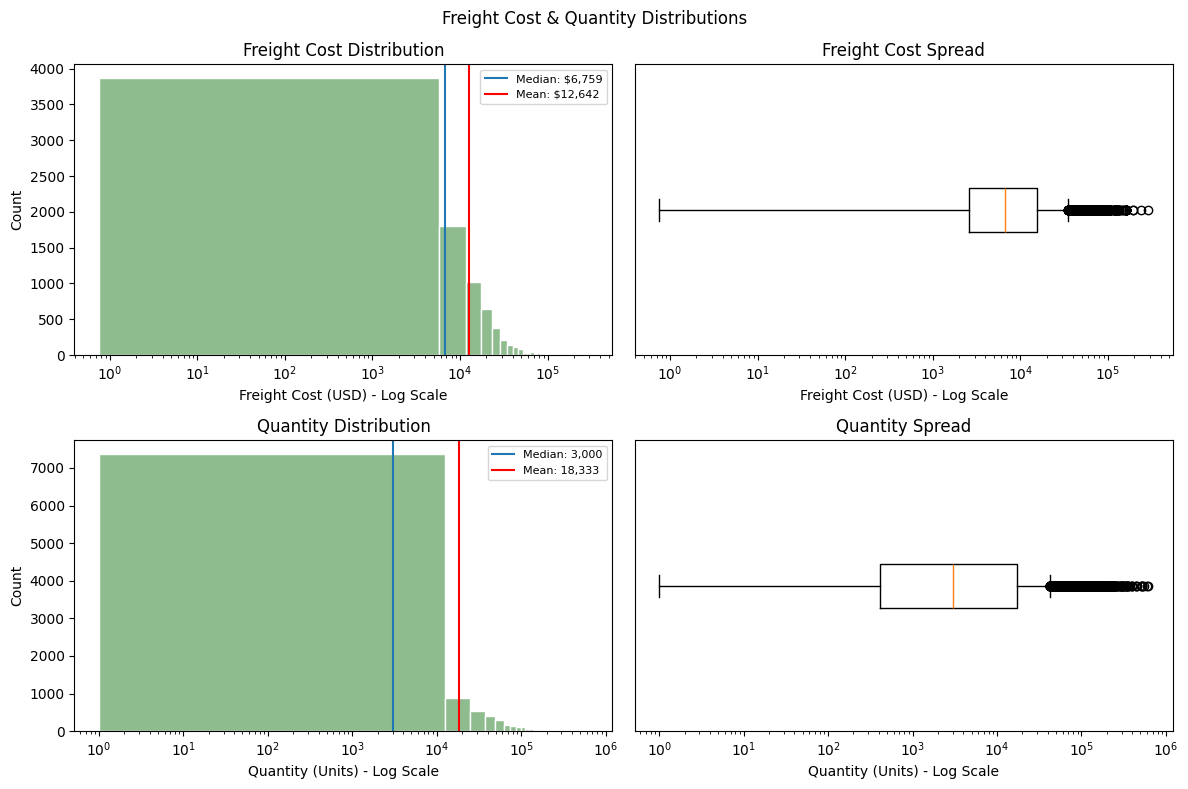

In [186]:
# filtering valid rows
fc  = scms_viz['Freight_Cost_USD'].dropna()
qty = scms_viz['Quantity'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Freight Cost & Quantity Distributions')

# Freight Cost - Histogram
axes[0, 0].hist(fc, bins=50, color='darkseagreen', edgecolor='white')
axes[0, 0].set_xscale('log')
axes[0, 0].axvline(fc.median(),label=f'Median: ${fc.median():,.0f}')
axes[0, 0].axvline(fc.mean(),color = 'red',label=f'Mean: ${fc.mean():,.0f}')
axes[0, 0].set_title('Freight Cost Distribution')
axes[0, 0].set_xlabel('Freight Cost (USD) - Log Scale')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(fontsize=8)

# Freight Cost - Boxplot
axes[0, 1].boxplot(fc, vert=False)
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Freight Cost Spread')
axes[0, 1].set_xlabel('Freight Cost (USD) - Log Scale')
axes[0, 1].set_yticks([])

# Quantity - Histogram
axes[1, 0].hist(qty, bins=50,color='darkseagreen', edgecolor='white')
axes[1, 0].set_xscale('log')
axes[1, 0].axvline(qty.median(),label=f'Median: {qty.median():,.0f}')
axes[1, 0].axvline(qty.mean(), color= 'red',label=f'Mean: {qty.mean():,.0f}')
axes[1, 0].set_title('Quantity Distribution')
axes[1, 0].set_xlabel('Quantity (Units) - Log Scale')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(fontsize=8)

# Quantity - Boxplot
axes[1, 1].boxplot(qty, vert=False)
axes[1, 1].set_xscale('log')
axes[1, 1].set_title('Quantity Spread')
axes[1, 1].set_xlabel('Quantity (Units) - Log Scale')
axes[1, 1].set_yticks([])

plt.tight_layout()
plt.show()

In [187]:
scms_viz['Quantity'].max()

619999

##### 1. Why did you pick the specific chart?

- A histogram shows how shipment costs and quantities are spread — whether most shipments are small, large, or mixed.
- A boxplot quickly highlights extreme values that could be inflating the program's overall logistics budget.

##### 2. What is/are the insight(s) found from the chart?

- Most shipments cost around \$6,759 to ship, but a few very expensive shipments push the average up to $12,642 — meaning a small number of costly shipments are skewing the budget picture.
- Most orders are relatively small (around 3,000 units), but some bulk orders go up to 619,999 units, which indicates uneven procurement planning across countries.
- Nearly 40% of freight cost records are missing or untrackable — a major gap in cost visibility for the program.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Positive:** Large bulk orders (high quantity) generally mean lower cost per unit, which is good for a donor-funded program trying to stretch every dollar.
- **Negative:** The few extremely high freight cost shipments suggest some deliveries may have been air-freighted unnecessarily, wasting donor funds that could have procured more medicines.
- **Negative:** With 40% of freight costs unrecorded, the program cannot accurately report total logistics spend to donors — this is a transparency and accountability risk.

#### Chart - 2 - Delivery Delay & Procurement Lead Time Distributions

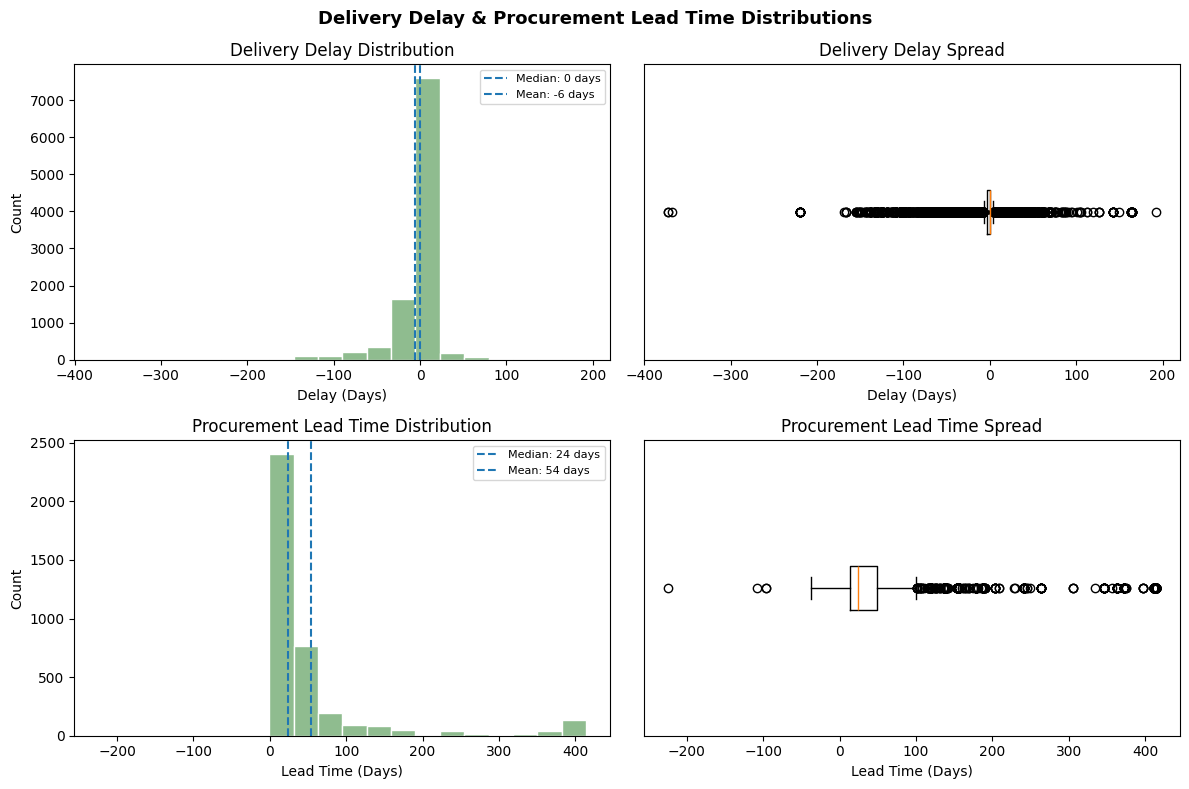

In [188]:
# Filter valid rows
delay = scms_viz['Delivery_Delay_Days'].dropna()
lead  = scms_viz['Procurement_Lead_Time'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Delivery Delay & Procurement Lead Time Distributions', fontsize=13, fontweight='bold')

# Delivery Delay - Histogram
axes[0, 0].hist(delay, bins=20, color='darkseagreen', edgecolor='white')
axes[0, 0].axvline(delay.median(), linestyle='--', label=f'Median: {delay.median():.0f} days')
axes[0, 0].axvline(delay.mean(),   linestyle='--', label=f'Mean: {delay.mean():.0f} days')
axes[0, 0].set_title('Delivery Delay Distribution')
axes[0, 0].set_xlabel('Delay (Days)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(fontsize=8)

# Delivery Delay - Boxplot
axes[0, 1].boxplot(delay, vert=False)
axes[0, 1].set_title('Delivery Delay Spread')
axes[0, 1].set_xlabel('Delay (Days)')
axes[0, 1].set_yticks([])

# Procurement Lead Time - Histogram
axes[1, 0].hist(lead, bins=20, color='darkseagreen', edgecolor='white')
axes[1, 0].axvline(lead.median(), linestyle='--', label=f'Median: {lead.median():.0f} days')
axes[1, 0].axvline(lead.mean(),   linestyle='--', label=f'Mean: {lead.mean():.0f} days')
axes[1, 0].set_title('Procurement Lead Time Distribution')
axes[1, 0].set_xlabel('Lead Time (Days)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(fontsize=8)

# Procurement Lead Time - Boxplot
axes[1, 1].boxplot(lead, vert=False)
axes[1, 1].set_title('Procurement Lead Time Spread')
axes[1, 1].set_xlabel('Lead Time (Days)')
axes[1, 1].set_yticks([])

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Choosing Histogram and Boxplot shows the average and distribution.

- Delivery delay directly answers whether medicines reached patients on time — the most critical question in a healthcare supply chain.
- Procurement lead time shows how long the ordering process takes before shipment even begins — a hidden delay that patients never see but always feel.

##### 2. What is/are the insight(s) found from the chart?

- Most shipments cluster around a small delay value even with an average of -6 days, but the long right tail shows a portion of shipments face severe delays — as visible from the gap between the mean and median lines on the chart.
- Negative delay values exist , but there are is an existance of late ones too - for ARV patients, even a few weeks gap can cause drug resistance.
- Procurement lead time also shows a wide spread — some orders move fast while others take significantly longer, suggesting inconsistent processes across vendors or countries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Positive:** The presence of early deliveries shows the supply chain is capable of efficiency — the question is why it doesn't happen consistently.
- **Negative:** The long tail in delivery delays means patients in some countries are waiting far longer than others for the same medicines — this is an equity issue, not just a logistics issue.
- **Negative:** High procurement lead times directly create stockout windows — if the ordering process is slow, there is a predictable gap where no medicines are in transit, putting treatment continuity at risk.

#### Chart - 3 - Countries and Vendors by Shipment Count

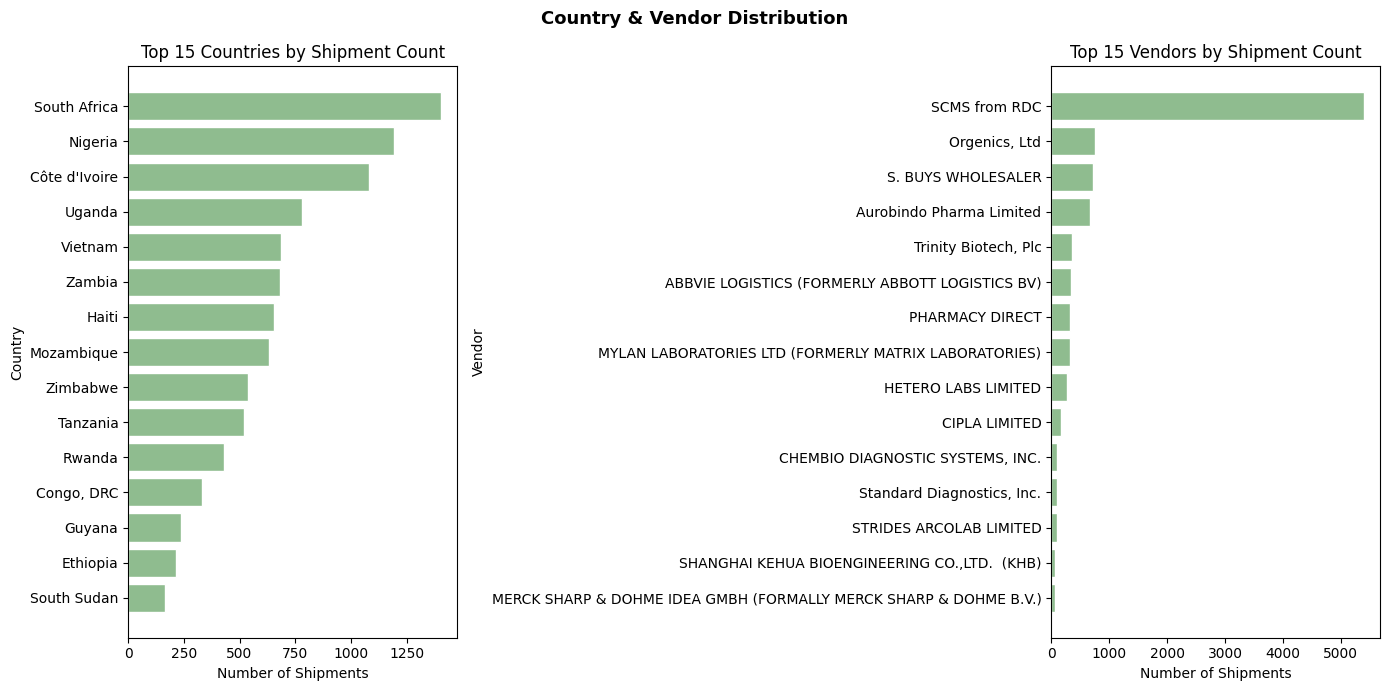

In [189]:
# Top 15 countries and vendors by shipment count
country_counts = scms_viz['Country'].value_counts().head(15)
vendor_counts  = scms_viz['Vendor'].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle('Country & Vendor Distribution', fontsize=13, fontweight='bold')

# Country bar chart
axes[0].barh(country_counts.index[::-1], country_counts.values[::-1], color='darkseagreen', edgecolor='white')
axes[0].set_title('Top 15 Countries by Shipment Count')
axes[0].set_xlabel('Number of Shipments')
axes[0].set_ylabel('Country')

# Vendor bar chart
axes[1].barh(vendor_counts.index[::-1], vendor_counts.values[::-1], color='darkseagreen', edgecolor='white')
axes[1].set_title('Top 15 Vendors by Shipment Count')
axes[1].set_xlabel('Number of Shipments')
axes[1].set_ylabel('Vendor')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

- A horizontal bar chart is the clearest way to rank and compare categories with long names — country and vendor names don't fit on a vertical axis.
- Seeing volume by country and vendor side by side reveals both geographic reach and supplier concentration in one view.

##### 2. What is/are the insight(s) found from the chart?

- South Africa leads with the highest shipment count (~1,400), followed closely by Nigeria and Côte d'Ivoire — the top 5 countries receive visibly more shipments than all others combined.
- SCMS from RDC stands out with a bar roughly 7× longer than the second vendor, Orgenics — a concentration that is immediately visible even without reading exact numbers.
- Despite 43 countries and 73 vendors in the dataset, the bar charts show most activity is concentrated in a small group at the top.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Positive:** High shipment volume to South Africa and Nigeria reflects prioritisation of the highest HIV-burden countries — donor funds are reaching where they are needed most.
- **Negative:** A single vendor handling over 50% of all shipments is a critical supply chain risk — if SCMS from RDC faces any disruption, it could collapse supply across multiple countries simultaneously.
- **Negative:** Low-volume countries receiving a small share of shipments may be the most underserved — high need does not always mean high supply in humanitarian programs.

#### Chart - 4 - Value counts -Shipment Mode, Product Group & Fulfill Via

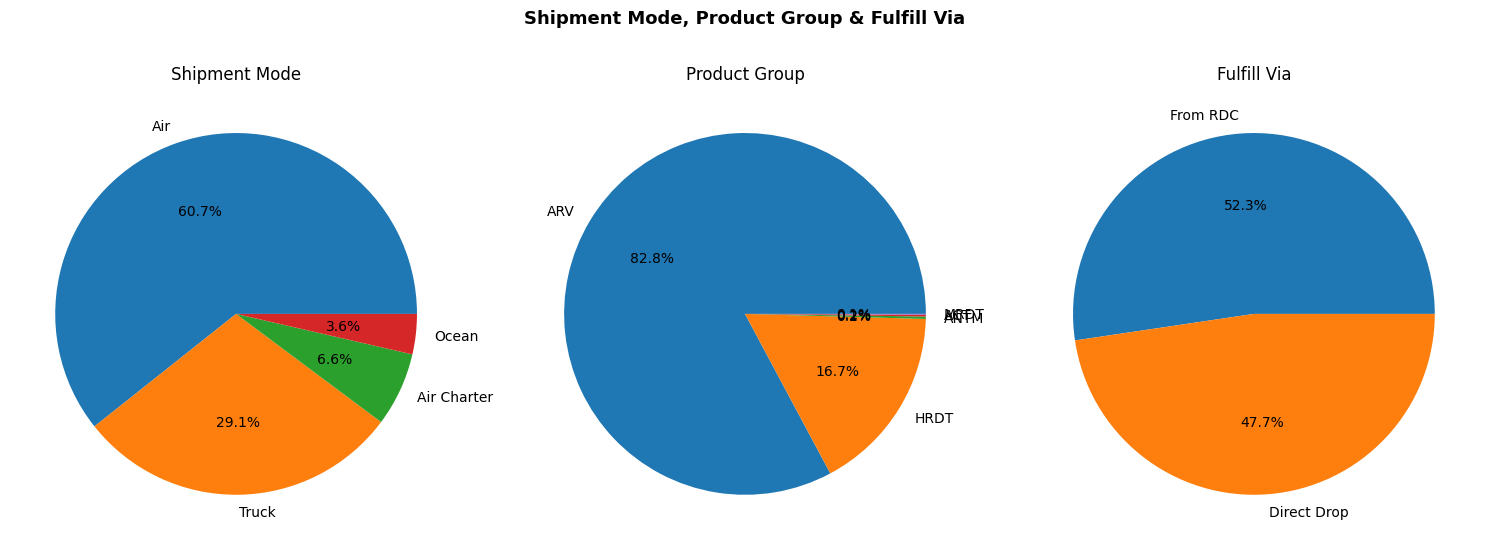

In [190]:
# Value counts for each categorical column
mode_data   = scms_viz['Shipment Mode'].value_counts()
product_data = scms_viz['Product Group'].value_counts()
fulfill_data = scms_viz['Fulfill Via'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Shipment Mode, Product Group & Fulfill Via', fontsize=13, fontweight='bold')

# Shipment Mode
axes[0].pie(mode_data.values, labels=mode_data.index, autopct='%1.1f%%')
axes[0].set_title('Shipment Mode')

# Product Group
axes[1].pie(product_data.values, labels=product_data.index, autopct='%1.1f%%')
axes[1].set_title('Product Group')

# Fulfill Via
axes[2].pie(fulfill_data.values, labels=fulfill_data.index, autopct='%1.1f%%')
axes[2].set_title('Fulfill Via')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

- Pie charts work well for low-cardinality columns where the goal is to show how the whole is split — each of these three columns has fewer than 5 categories.
- Grouping all three in one row allows a quick read of the entire operational structure — how goods move, what they are, and through which channel.

##### 2. What is/are the insight(s) found from the chart?

- Air freight dominates at 60.7%, and when Air Charter (6.6%) is added, over 67% of all shipments move by air — the most expensive mode available.
- ARV medicines make up 82.8% of all shipments, confirming this is essentially an HIV treatment supply chain with small volumes of other products.
- Fulfill Via is nearly an even split — 52.3% through RDC and 47.7% Direct Drop — meaning both channels are actively used at similar scale.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Positive:** The near 50-50 split in Fulfill Via shows the program has two functioning distribution channels — reducing single-channel dependency risk.
- **Negative:** 67% air freight for routine, predictable ARV shipments is a donor budget concern — air costs significantly more than ocean freight and should be reserved for emergencies, not standard supply runs.
- **Negative:** ARV dominance at 82.8% means any supply disruption — vendor failure, freight delay, or procurement breakdown — hits HIV patients almost exclusively, making reliability a patient safety issue, not just a logistics metric.

# BIVARIATE ANALYSIS

#### Chart - 5 - Shipment Mode Vs Delivery Delays

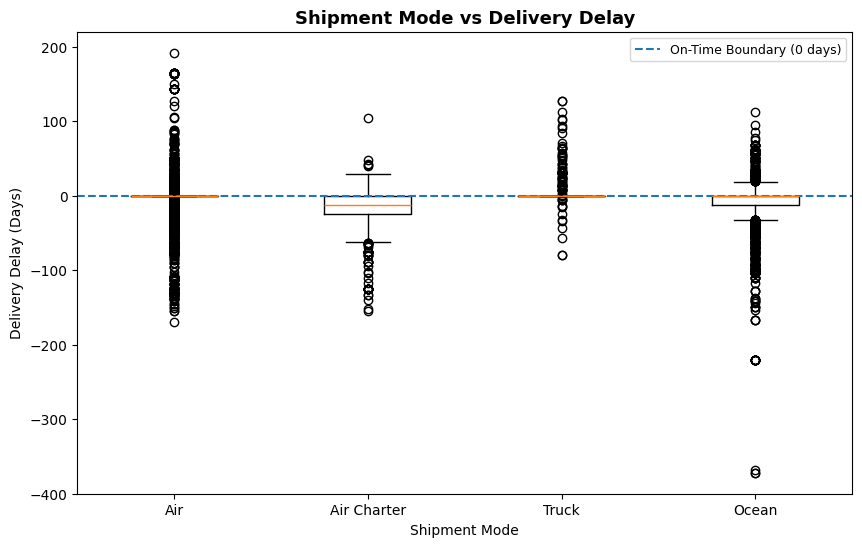

In [191]:
# Preparing data — one list per mode
modes = ['Air', 'Air Charter', 'Truck', 'Ocean']
delay_by_mode = (
    scms_viz
    .dropna(subset=['Delivery_Delay_Days'])
    .groupby('Shipment Mode')['Delivery_Delay_Days']
    .apply(lambda x: x.values)
    .tolist()
)


fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(delay_by_mode,labels = modes)
ax.axhline(0,linestyle='--', label='On-Time Boundary (0 days)')
ax.set_title('Shipment Mode vs Delivery Delay', fontsize=13, fontweight='bold')
ax.set_xlabel('Shipment Mode')
ax.set_ylabel('Delivery Delay (Days)')
ax.legend(fontsize=9)


plt.show()

##### 1. Why did you pick the specific chart?

- A grouped boxplot compares the delay distribution across all shipment modes at once — we can see the median, spread, and outliers for each mode in a single view.
- The reference line at zero separates early/on-time deliveries from late ones, making it easy to see which modes consistently miss deadlines.

##### 2. What is/are the insight(s) found from the chart?

- Air Charter has the lowest median delay box — its median line sits clearly below zero, meaning most Air Charter shipments arrive ahead of schedule.
- Ocean freight's box sits highest relative to the zero line — its median is at zero but it has more spread into positive delay than other modes.
- All four modes show outliers on both sides, but the spread of Ocean and Air boxes extends further into late delivery territory compared to Truck and Air Charter.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Positive:** Air Charter, despite being the most expensive mode, delivers earliest — it may be justified for urgent or time-sensitive medicines where treatment continuity is at risk.
- **Negative:** Ocean freight shows the weakest delay performance — if the program shifts routine shipments to ocean to save freight costs, it risks pushing more deliveries past the deadline.
- **Negative:** Air is the most-used mode at 60.7% of shipments, yet its delay performance is not the best — the program is paying premium freight costs without consistently getting the fastest delivery in return.

#### Chart - 6 - Delivery Delay by Countries

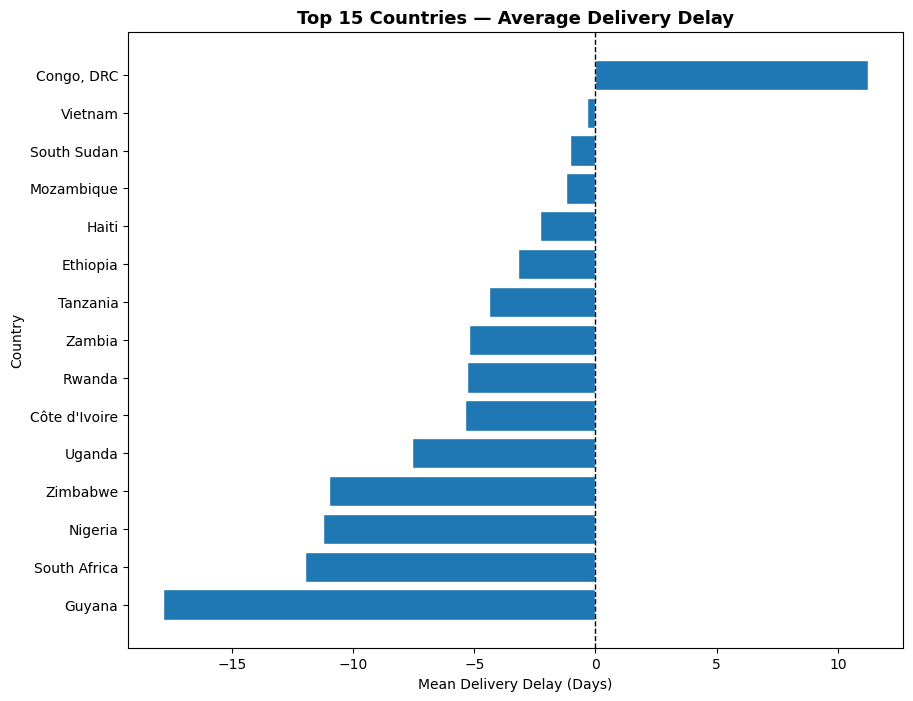

In [192]:
# Chart - 6 visualization code
# Top 15 countries by shipment count
top15 = scms_viz['Country'].value_counts().head(15).index.tolist()
df_top15 = scms_viz[scms_viz['Country'].isin(top15)]

# Mean delay per country, sorted worst to best
country_delay = df_top15.groupby('Country')['Delivery_Delay_Days'].mean().reindex(top15)
country_delay = country_delay.sort_values(ascending=True)


fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(country_delay.index, country_delay.values,edgecolor='white')
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Top 15 Countries — Average Delivery Delay', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Delivery Delay (Days)')
ax.set_ylabel('Country')

plt.show()

##### 1. Why did you pick the specific chart?

- A horizontal bar chart ranked by mean delay makes it immediately clear which countries are chronically underserved versus well-supplied.

##### 2. What is/are the insight(s) found from the chart?

- Congo DRC is the only country with a bar extending to the right of the zero line — meaning it is the only country among the top 15 where shipments arrive late on average.
- Guyana, South Africa, and Nigeria have the longest bars on the early side — these countries consistently receive shipments well ahead of schedule.
- Vietnam, South Sudan, and Mozambique sit closest to the zero line — their deliveries are barely on time, with very little buffer.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Positive:** Most high-volume countries show early or on-time delivery — the supply chain is broadly working for countries that receive frequent shipments.
- **Negative:** Congo DRC's position as the only late-average country among the busiest is a red flag —  patients there face a structurally unreliable supply chain.
- **Negative:** Countries near the zero line like Vietnam and South Sudan have no delivery buffer — any small disruption in logistics or procurement pushes them into stockout territory immediately.

#### Chart - 7 - Reliable Vendors

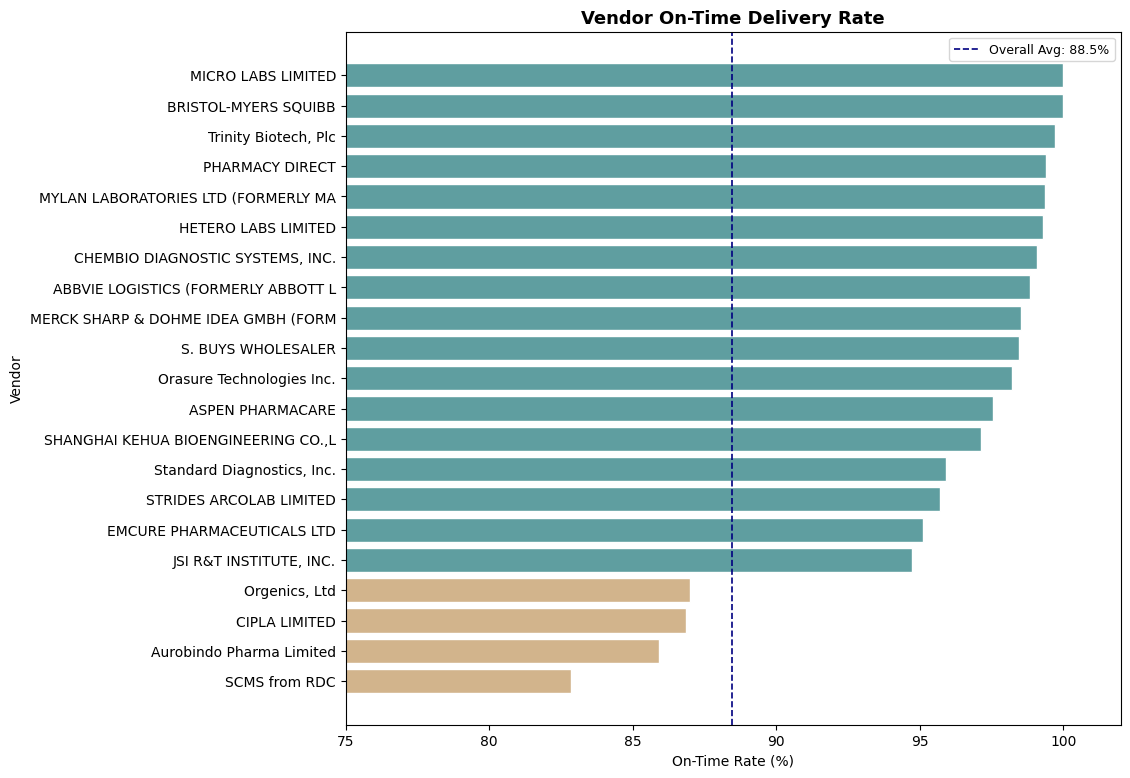

In [193]:
# Chart - 7 visualization code
# Vendors with 30+ shipments for reliability
vendor_counts = scms_viz['Vendor'].value_counts()
active_vendors = vendor_counts[vendor_counts >= 30].index

df_active = scms_viz[scms_viz['Vendor'].isin(active_vendors)]

# On-time rate per vendor, sorted ascending so best appears at top
vendor_ontime = df_active.groupby('Vendor')['On_Time_Flag'].mean() * 100
vendor_ontime = vendor_ontime.sort_values(ascending=True)

# Truncating long vendor names for readability
vendor_ontime.index = [name[:35] for name in vendor_ontime.index]

# Color: below overall average = tan, above =cadetblue
overall_avg = scms_viz['On_Time_Flag'].mean() * 100
bar_colors = ['tan' if x < overall_avg else 'cadetblue' for x in vendor_ontime.values]

fig, ax = plt.subplots(figsize=(10, 9))

ax.barh(vendor_ontime.index, vendor_ontime.values, color=bar_colors, edgecolor='white')
ax.axvline(overall_avg, color='navy', linestyle='--', linewidth=1.2,
           label=f'Overall Avg: {overall_avg:.1f}%')
ax.set_title('Vendor On-Time Delivery Rate', fontsize=13, fontweight='bold')
ax.set_xlabel('On-Time Rate (%)')
ax.set_ylabel('Vendor')
ax.set_xlim(75, 102)
ax.legend(fontsize=9)

plt.show()

##### 1. Why did you pick the specific chart?

- A ranked horizontal bar chart with a reference line makes vendor performance comparison immediate — no table reading needed.
- Color coding separates underperforming vendors from reliable ones relative to the program average shown by the dotted line.

##### 2. What is/are the insight(s) found from the chart?

- Bristol-Myers Squibb and Micro Labs Limited hit 100% on-time rate, and three other vendors sit above 99% — these vendors are operationally reliable.
- SCMS from RDC, the largest vendor handling over half of all shipments, falls below the program average line with an on-time rate clearly in the red zone.
- Aurobindo Pharma and CIPLA, both high-volume vendors, also fall below the average line — meaning the program's most-used suppliers are not its most reliable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Positive:** Several vendors maintain near-perfect on-time rates — the program can use these as benchmarks and prioritise them for critical or time-sensitive orders.
- **Negative:** SCMS from RDC's below-average performance is a systemic risk — with over 5,000 shipments routed through one underperforming vendor, even a 1% reliability drop translates to dozens of delayed medicine deliveries.
- **Negative:** High-volume vendors underperforming while smaller vendors hit 100% suggests the program may benefit from redistributing order volume toward more reliable suppliers.

#### Chart - 8

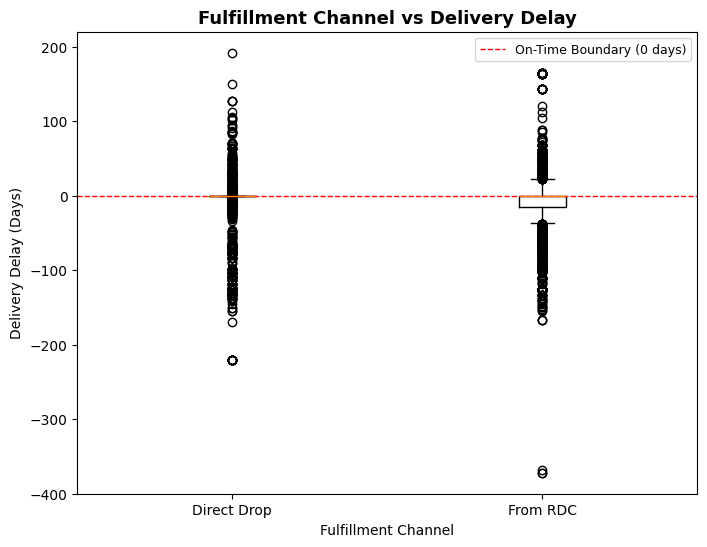

In [194]:
# Chart - 8 visualization code
# Delivery delay by fulfillment channel
channels = ['Direct Drop', 'From RDC']
delay_by_channel = (
    scms_viz
    .dropna(subset=['Delivery_Delay_Days'])
    .groupby('Fulfill Via')['Delivery_Delay_Days']
    .apply(lambda x: x.values)
    .tolist()
)


fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(delay_by_channel, labels=channels)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='On-Time Boundary (0 days)')
ax.set_title('Fulfillment Channel vs Delivery Delay', fontsize=13, fontweight='bold')
ax.set_xlabel('Fulfillment Channel')
ax.set_ylabel('Delivery Delay (Days)')
ax.legend(fontsize=9)


plt.show()

##### 1. Why did you pick the specific chart?

- A side-by-side boxplot is the clearest way to compare two distributions — it shows median, spread, and outliers for both channels in one frame.
- With only two categories, this chart makes the performance gap between channels immediately readable without any calculations.

##### 2. What is/are the insight(s) found from the chart?

- Both channels share the same median line at zero — meaning the typical shipment arrives on time regardless of channel.
- From RDC's box extends further below zero, showing it delivers earlier more often than Direct Drop when things go well.
- However, From RDC also has visibly more outlier points above the zero line — it produces more late-delivery exceptions than Direct Drop.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Positive:** Direct Drop shows a tighter, more consistent box — it is the more predictable channel, which matters for countries that need reliable supply planning.
- **Negative:** From RDC's wider spread and higher outlier count above zero means patients routed through this channel face a less predictable supply — good deliveries are very good, but failures are more frequent.
- **Negative:** Since From RDC handles 52% of all shipments, its higher rate of late outliers has a larger absolute impact on patient access than the same rate would from a smaller channel.

#### Chart - 9 - Shipment Mode Vs Freight Cost

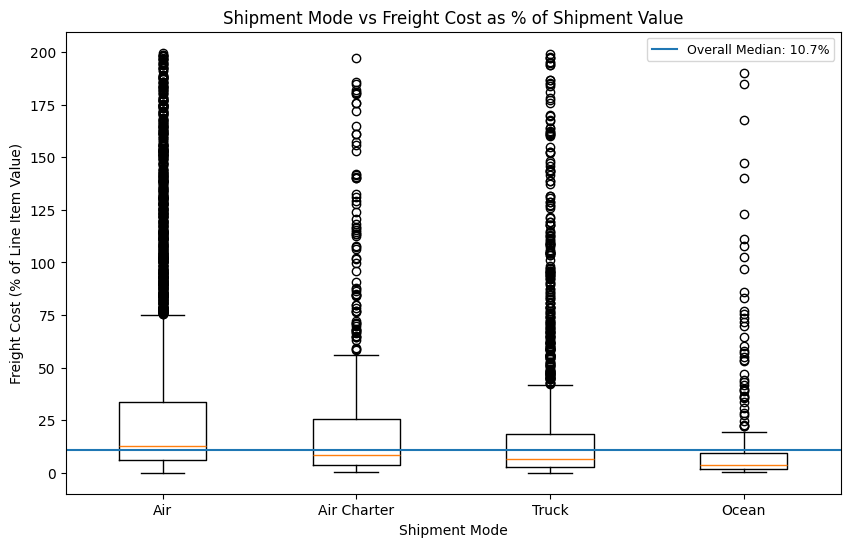

In [195]:
# Chart - 9 visualization code
# Capping extreme values at 200% for clean visualization
df_sm_fc = scms_viz[scms_viz['Freight_Pct_Value'].notna()].copy()
df_sm_fc = df_sm_fc[df_sm_fc['Freight_Pct_Value'] <= 200]

# Order modes from most to least expensive
modes = ['Air', 'Air Charter', 'Truck', 'Ocean']
freight_by_mode = [df_sm_fc[df_sm_fc['Shipment Mode'] == m]['Freight_Pct_Value'].dropna().values
                   for m in modes]

fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(freight_by_mode, labels=modes)
ax.axhline(df_sm_fc['Freight_Pct_Value'].median(), label=f'Overall Median: {df_sm_fc["Freight_Pct_Value"].median():.1f}%')
ax.set_title('Shipment Mode vs Freight Cost as % of Shipment Value')
ax.set_xlabel('Shipment Mode')
ax.set_ylabel('Freight Cost (% of Line Item Value)')
ax.legend(fontsize=9)

plt.show()

In [196]:
# Median for Ocean shipments
print(df_sm_fc[df_sm_fc['Shipment Mode'] == 'Ocean']['Freight_Pct_Value'].median())

# Median for Air shipments
print(df_sm_fc[df_sm_fc['Shipment Mode'] == 'Air']['Freight_Pct_Value'].median())

3.491256529725736
12.867521706903613


##### 1. Why did you pick the specific chart?

- Freight cost as a percentage of shipment value is a fairer budget efficiency measure than raw freight cost — it accounts for shipment size and shows how much of the donor's money goes purely to moving goods versus buying medicines.
- A boxplot per mode shows not just the typical freight burden but also how wildly it varies within each mode.

##### 2. What is/are the insight(s) found from the chart?

- Ocean freight's median sits clearly the lowest on the chart — a typical ocean shipment spends around 3-4% of its value on freight, far below all other modes.
- Air freight's median is the highest, sitting above the overall program average line — a typical air shipment spends over 16% of its value just on transportation.
- Air Charter's median falls below Air despite being a premium service — its box sits closer to Truck than to Air, suggesting it is used for high-value shipments where freight cost dilutes proportionally.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Positive:** Ocean freight's low freight percentage shows it is the most donor-efficient mode — for every dollar spent on an ocean shipment, far more goes toward the medicine itself.
- **Negative:** Air freight at over 16% median freight burden means for every $100 of ARV medicines shipped by air, more than \$16 is spent just on moving the box — money that could instead procure additional doses.
- **Negative:** Given air handles 60.7% of all shipments, the program is routinely absorbing a high freight cost premium at scale — a structural shift toward sea freight for non-urgent orders could free up significant donor budget.

#### Chart - 10 - Order time vs Delivery Delay

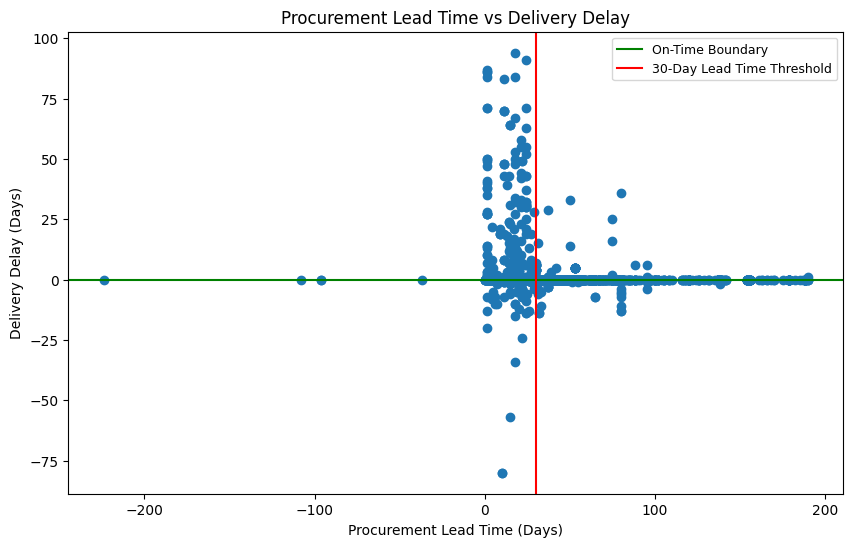

In [197]:
# Chart - 10 visualization code
# Filtering valid rows and cap for clean visualization
df_b6 = scms_viz[['Procurement_Lead_Time', 'Delivery_Delay_Days']].dropna()
df_b6 = df_b6[(df_b6['Procurement_Lead_Time'] <= 200) & (df_b6['Delivery_Delay_Days'].between(-100, 100))]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_b6['Procurement_Lead_Time'], df_b6['Delivery_Delay_Days'])

ax.axhline(0,color = 'green',label='On-Time Boundary')
ax.axvline(30,color = 'red',label='30-Day Lead Time Threshold')

ax.set_title('Procurement Lead Time vs Delivery Delay')
ax.set_xlabel('Procurement Lead Time (Days)')
ax.set_ylabel('Delivery Delay (Days)')
ax.legend(fontsize=9)

plt.show()

##### 1. Why did you pick the specific chart?

- A scatter plot is the right choice when checking whether two numbers move together — here, the question is whether a longer ordering process leads to later delivery.
- Each dot is one shipment, so the chart shows the full picture without hiding exceptions behind averages.

##### 2. What is/are the insight(s) found from the chart?

- The dots show no clear upward or downward slope — shipments with long procurement lead times are not noticeably more delayed than those with short lead times.
- The bulk of late deliveries (dots above the green line) are concentrated in the left half of the chart — meaning shipments with fast procurement cycles are actually more likely to arrive late.
- Most dots across all lead time values cluster below the zero line, confirming that the majority of shipments arrive on time regardless of how long procurement took.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Positive:** Long procurement cycles do not automatically mean late deliveries — the logistics leg of the supply chain appears to compensate and still deliver on time even when ordering is slow.
- **Negative:** Late deliveries clustering in the fast procurement zone suggests these are likely emergency or last-minute orders — reactive procurement is a supply chain failure, not a sign of agility.
- **Negative:** The lack of any relationship between these two variables points to poor planning visibility — the program is not using procurement lead time as an early warning tool, and instead reacting to shortages rather than preventing them.

# MULTIVARIATE ANALYSIS

#### Chart - 11 - Yearly Shipment Volume and On-Time Rate

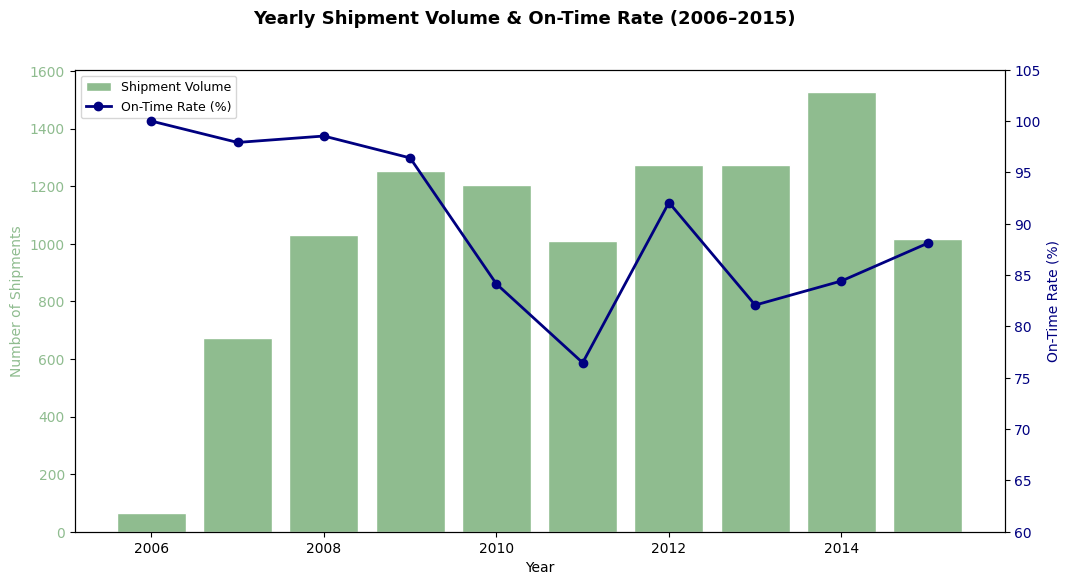

In [198]:
# Chart - 11 visualization code
yearly = scms_viz.groupby('Year').agg(
    Shipments=('ID', 'count'),
    OnTime_Rate=('On_Time_Flag', 'mean')
).reset_index()
yearly['OnTime_Rate'] = yearly['OnTime_Rate'] * 100

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart — shipment volume
ax1.bar(yearly['Year'], yearly['Shipments'], color='darkseagreen',
        edgecolor='white', label='Shipment Volume')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Shipments', color='darkseagreen')
ax1.tick_params(axis='y', labelcolor='darkseagreen')

# Line chart — on-time rate on secondary axis
ax2 = ax1.twinx()
ax2.plot(yearly['Year'], yearly['OnTime_Rate'], color='navy',
         marker='o', linewidth=2, label='On-Time Rate (%)')
ax2.set_ylabel('On-Time Rate (%)', color='navy')
ax2.tick_params(axis='y', labelcolor='navy')
ax2.set_ylim(60, 105)

fig.suptitle('Yearly Shipment Volume & On-Time Rate (2006–2015)',
             fontsize=13, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')


plt.show()

##### 1. Why did you pick the specific chart?

- A dual-axis combo chart is the best way to show two different scales on the same timeline — bar heights show how the program grew, while the line tracks whether quality kept pace with that growth.
- Seeing both together reveals whether scale came at the cost of reliability.

##### 2. What is/are the insight(s) found from the chart?

- Shipment volume grew steadily from near zero in 2006 to a peak in 2014, showing strong program expansion over the decade.
- The on-time rate line drops sharply between 2009 and 2011 — hitting its lowest point at 75% — when volume was growing fastest.
- After 2011, the line recovers gradually, reaching almost 90% by 2015, even as volume remained high.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Positive:** The recovery in on-time rate after 2011 while maintaining high volume shows the program adapted — operational improvements were made mid-program without scaling back supply.
- **Negative:** The 2011 dip to 75% on-time rate during peak growth means shipments were late at the program's most critical expansion phase — a period when the most new patients were likely entering treatment.
- **Negative:** Volume dropped in 2015 despite the on-time rate improving — this could indicate budget cuts or procurement slowdowns, raising questions about whether supply kept up with actual patient demand in the final year.

#### Chart - 12 - Quarterly Analysis

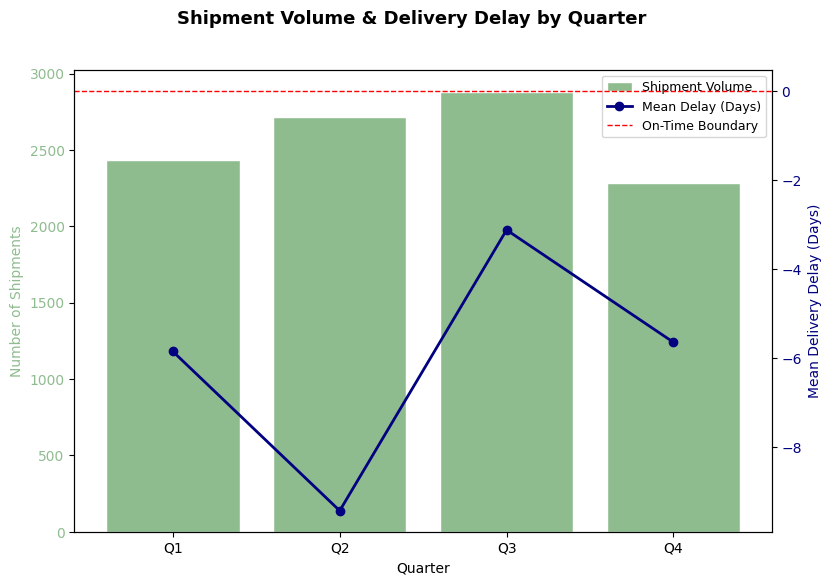

In [199]:
# Aggregate by quarter across all years
quarterly = scms_viz.groupby('Quarter').agg(
    Shipments=('ID', 'count'),
    Mean_Delay=('Delivery_Delay_Days', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(9, 6))

# Bar chart — shipment volume
ax1.bar(quarterly['Quarter'], quarterly['Shipments'],
        color='darkseagreen', edgecolor='white', label='Shipment Volume')
ax1.set_xlabel('Quarter')
ax1.set_ylabel('Number of Shipments', color='darkseagreen')
ax1.tick_params(axis='y', labelcolor='darkseagreen')
ax1.set_xticks([1, 2, 3, 4])
ax1.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])

# Line chart — mean delay on secondary axis
ax2 = ax1.twinx()
ax2.plot(quarterly['Quarter'], quarterly['Mean_Delay'],
         color='navy', marker='o', linewidth=2, label='Mean Delay (Days)')
ax2.axhline(0, color='red', linestyle='--', linewidth=1, label='On-Time Boundary')
ax2.set_ylabel('Mean Delivery Delay (Days)', color='navy')
ax2.tick_params(axis='y', labelcolor='navy')

fig.suptitle('Shipment Volume & Delivery Delay by Quarter',
             fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')

plt.tight_layout
plt.show()

##### 1. Why did you pick the specific chart?

- A combo chart with bars and a line on the same quarter axis shows whether procurement peaks align with better or worse delivery performance — a pure bar chart alone would miss that relationship.
- Grouping by quarter across all years smooths out year-specific noise and reveals the true seasonal pattern of the program.



##### 2. What is/are the insight(s) found from the chart?

- Q3 has the tallest bar, making it the busiest shipment quarter — the program consistently ships the most medicines between July and September.
- Q4 has the shortest bar, showing the lowest shipment activity — procurement slows significantly in the final quarter of the year.
- The mean delay line sits furthest below zero in Q2, showing Q2 shipments arrive the earliest on average despite being the second highest volume quarter.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Positive:** Q2 and Q3 together handle the bulk of shipments and both show negative mean delays — the peak procurement period is also the best-performing period, suggesting operational readiness aligns with demand.
- **Negative:** Q4's low volume is a procurement planning risk — a drop in shipments in the last quarter creates a predictable supply gap entering Q1, when patients may face shortages before the new procurement cycle picks up.
- **Negative:** The uneven distribution across quarters shows reactive rather than planned procurement — a well-managed humanitarian supply chain should maintain consistent monthly volumes to avoid stockout windows between peaks



#### Chart - 13 - Vendor Score Card

In [200]:
import plotly.express as px

# Vendors with 30+ shipments, exclude extreme freight outlier
vendor_counts = scms_viz['Vendor'].value_counts()
active = vendor_counts[vendor_counts >= 30].index

df_vendor = scms_viz[scms_viz['Vendor'].isin(active)].copy()

summary = df_vendor.groupby('Vendor').agg(
    Mean_Delay=('Delivery_Delay_Days', 'mean'),
    Median_Freight_Pct=('Freight_Pct_Value', 'median'),
    Shipments=('ID', 'count')
).dropna().reset_index()

summary = summary[summary['Median_Freight_Pct'] <= 100]

fig = px.scatter(summary,
                 x='Mean_Delay',
                 y='Median_Freight_Pct',
                 size='Shipments',
                 hover_name='Vendor',
                 title='Vendor — Delivery Delay vs Freight Cost % (Bubble size = Shipment Volume)',
                 labels={'Mean_Delay': 'Mean Delivery Delay (Days)',
                         'Median_Freight_Pct': 'Median Freight Cost (% of Shipment Value)'})

fig.add_vline(x=0, annotation_text='On-Time Boundary')
fig.add_hline(y=summary['Median_Freight_Pct'].median(), line_dash='dash',
              line_color='navy', annotation_text='Median Freight %')

fig.update_layout(template ='plotly_white')
fig.show()

##### 1. Why did you pick the specific chart?

- A bubble chart maps three variables at once — delay on the x-axis, freight cost burden on the y-axis, and shipment volume as bubble size — making it a vendor scorecard in one view.
- The four quadrants created by the two reference lines immediately separate reliable low-cost vendors from expensive or unreliable ones.

##### 2. What is/are the insight(s) found from the chart?

- Vendors with bubbles in the bottom-left quadrant (below median freight line, left of zero delay) are the best value — they deliver early and cost less to ship.
- CIPLA and Aurobindo sit to the right of the zero line with moderate freight costs — they are the only vendors delivering late on average, visible as the rightmost bubbles on the chart.
- The largest bubble (SCMS from RDC) sits left of zero but its size dominates the chart — any cost or delay shift in this single vendor moves the entire program's performance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- **Positive:** Several small-to-medium vendors occupy the ideal bottom-left quadrant — they can be prioritised for critical ARV orders where reliability and cost efficiency both matter.
- **Negative:** CIPLA and Aurobindo together handle a significant shipment volume and both show positive mean delays — the program is routing large volumes through vendors with below-average delivery performance.
- **Negative:** The dominance of one bubble (SCMS from RDC) over all others is a visual risk signal — vendor concentration this extreme means the program has no true fallback if its primary vendor underperforms.

#### Chart - 14 - Correlation Heatmap

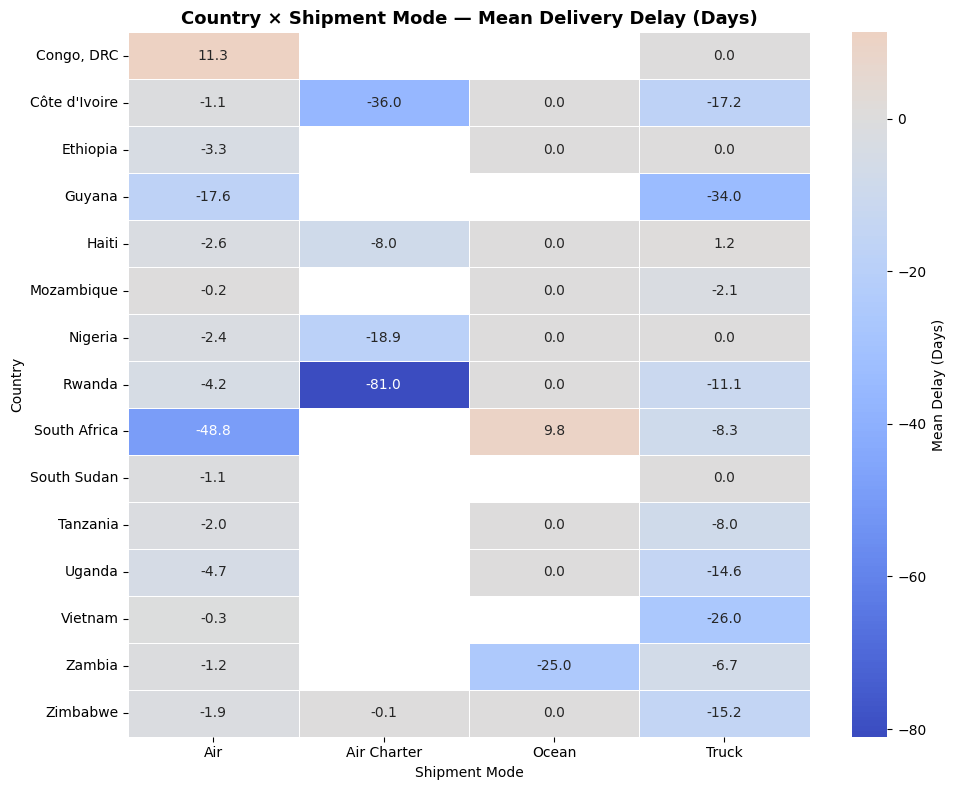

In [201]:
# Top 15 countries pivot
top15 = scms_viz['Country'].value_counts().head(15).index.tolist()
df_m2 = scms_viz[scms_viz['Country'].isin(top15)]

pivot = df_m2.pivot_table(
    values='Delivery_Delay_Days',
    index='Country',
    columns='Shipment Mode',
    aggfunc='mean'
).round(1)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Mean Delay (Days)'}, ax=ax)

ax.set_title('Country × Shipment Mode — Mean Delivery Delay (Days)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Shipment Mode')
ax.set_ylabel('Country')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

- A heatmap is the most effective way to show a two-dimensional risk matrix — country on one axis, shipment mode on the other, and delay shown through color and annotated values simultaneously.
- Red cells immediately flag dangerous country-mode combinations.

##### 2. What is/are the insight(s) found from the chart?

- Congo DRC via Air is the only clearly pink cell in the matrix, showing a mean delay of 11.3 days — the single most at-risk country-mode combination in the program.
- South Africa via Ocean shows 9.8 days mean delay, while its Air cell is deeply blue — this country performs very differently depending on which mode is used.
- Several cells are empty, meaning certain country-mode combinations are never used — Air Charter and Ocean have the most gaps, showing they are not universally available routes.

#### Chart - 15 - Pair Plot

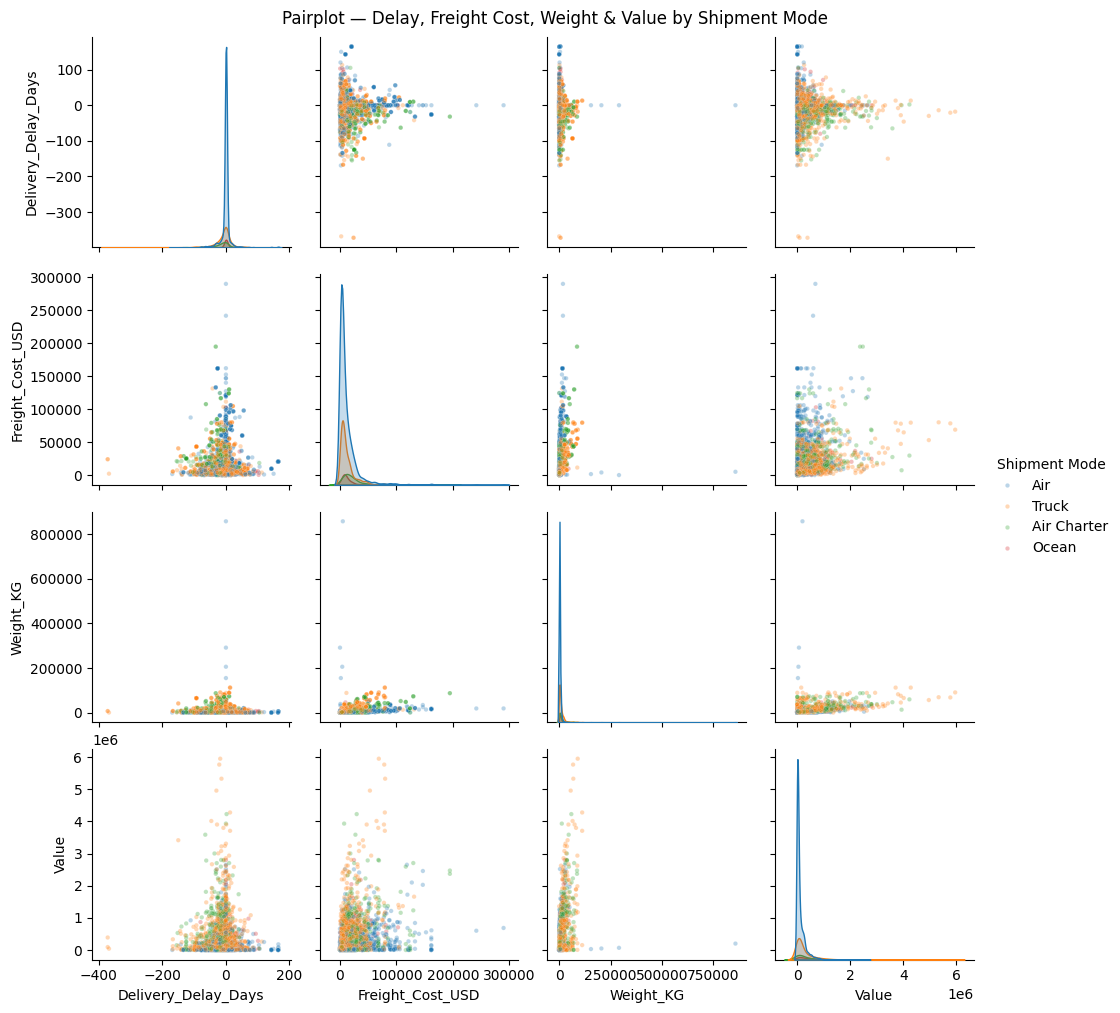

In [202]:
cols = ['Delivery_Delay_Days', 'Freight_Cost_USD', 'Weight_KG', 'Value', 'Shipment Mode']
df_pair = scms_viz[cols].dropna()

g = sns.pairplot(df_pair, hue='Shipment Mode',
                 vars=['Delivery_Delay_Days', 'Freight_Cost_USD', 'Weight_KG', 'Value'],
                 plot_kws={'alpha': 0.3, 's': 10})

g.fig.suptitle('Pairplot — Delay, Freight Cost, Weight & Value by Shipment Mode',
               y=1.01)

plt.show()

##### 1. Why did you pick the specific chart?

- A pairplot shows every variable plotted against every other variable at once — it is the most efficient way to spot relationships across multiple dimensions in one view.
- Coloring by Shipment Mode adds a third layer, revealing whether different transport methods carry fundamentally different types of cargo.

##### 2. What is/are the insight(s) found from the chart?

- Freight Cost and Weight show the clearest positive relationship — as shipment weight increases, freight cost rises, and this pattern is visible across all modes.
- Ocean shipments (green dots) cluster at high Weight and high Value but low Freight Cost — confirming ocean carries the heaviest, most valuable cargo at the lowest freight spend.
- Air shipments (blue dots) are spread widely across all weight and value ranges — air is not reserved for light or high-value cargo, it is used indiscriminately across shipment types.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

**Business Objective Recommendations**

The core objective is to ensure uninterrupted ARV medicine supply to HIV patients across 43 countries while maximising donor budget efficiency.

**1. Shift routine shipments from Air to Ocean**
Over 67% of shipments move by air. Ocean freight carries heavier, higher-value cargo at a fraction of the cost. Redirecting non-urgent ARV orders to ocean would free significant donor budget without compromising delivery timelines.

**2. Reduce vendor concentration risk**
SCMS from RDC handles over 50% of all shipments but performs below the program's average on-time rate. Redistributing volume toward high-reliability vendors like Bristol-Myers Squibb and Trinity Biotech reduces single-point failure risk.

**3. Prioritise Congo DRC for immediate intervention**
It is the only country among the top 15 where shipments arrive late on average — and even air freight fails there. This points to a country-level logistics problem requiring dedicated attention beyond standard mode or vendor fixes.

**4. Fix Q4 procurement drop**
Shipment volume consistently falls in Q4, creating a predictable supply gap at year-end. Smoothing procurement across all four quarters would eliminate this recurring stockout window before it reaches patients.

**5. Resolve the 40% untracked freight cost gap**
Nearly 40% of freight cost records are non-numeric. Without resolving this, the program cannot accurately report logistics spend to donors — a direct accountability and audit risk.

# **Conclusion**

**EDA Conclusion**

This analysis examined 10,324 shipment records across a PEPFAR/USAID-funded supply chain spanning 2006–2015, covering 43 countries, 73 vendors, and over $1.63 billion in shipment value.

**What works:** 88.5% of shipments arrive on time, volume grew consistently through 2014, and several vendors maintain 100% on-time rates — proving the supply chain is capable of excellence.

**What doesn't:** Air freight dominates at 67% despite being the most expensive mode. One vendor handles 50% of all shipments while performing below average. Congo DRC fails even with air freight. Q4 records a predictable supply gap every year. 40% of freight costs are untracked.

**Why it matters:** 82.8% of shipments are ARVs. Every delay is a gap in HIV therapy — not a missed deadline. Every wasted freight dollar is a dose not procured.

**The verdict:** This is not a broken supply chain — it is an under-optimised one. The inefficiencies are concentrated, repeatable, and fixable. Shifting freight modes, redistributing vendor volume, and stabilising quarterly procurement would meaningfully improve patient access without requiring additional donor funding.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***